# WP3 — Africa Multi‑Hazard Prioritisation Tool (Country + Regional)

This notebook turns the **intermediate long table** (country × hazard × indicator) into:

- **Dimension scores** (5 dimensions) per **country × hazard**
- **Hazard scores & rankings** per **country**
- **Regional hazard prioritisation** per **region** (both **population‑weighted** and **unweighted**)
- **Explainability**: exactly *which indicators* contributed to each score, and how sensitive results are to key rules

---

## Inputs (edit only if your folder structure changes)

- Indicators long table: `C:\pipelines\sewa-multihazar\data\intermediate\wp3_country_indicators_long.csv`
- Population (World Bank WDI): `C:\pipelines\sewa-multihazar\data\raw\population\API_SP.POP.TOTL_DS2_en_csv_v2_34.zip`

> **Population definition (WDI SP.POP.TOTL):** de‑facto population, **mid‑year estimates**  
> Source: World Bank WDI metadata glossary (SP.POP.TOTL)

---

## What this notebook is (and is not)

✅ **It is** a transparent, scenario‑driven prioritisation tool that lets you compare:
- Overlap handling (e.g., EM‑DAT vs DesInventar on the same construct)
- Inclusion of hazard‑agnostic indicators **per hazard**
- Population‑weighted vs unweighted regional aggregation

❌ **It is not** a dataset extraction notebook. Extraction happens upstream (WP3_01…WP3_06 notebooks).

---


## Normalisation & Indicator Selection

### Data-Driven Indicator Curation (Jan 2026)

**A comprehensive diagnostic analysis** was performed to ensure robustness and explainability. Based on statistical evidence, **63 indicators were removed** from the framework (46% reduction from 138 to 75 indicators).

#### Key Decisions:

**1. INFORM vs WRI Scale Indicators**
- **Analysis:** Head-to-head comparison on Coverage, Variance, Stability, Hazard Breadth
- **Result:** Statistical tie (WRI marginally higher variance: 0.0751 vs 0.0750)
- **Decision:** **Keep INFORM** (UN/humanitarian institutional standard) + **Remove WRI.EI_03/04/05**
  - WRI.EI_04 ↔ INFORM.HAZEX.RIVER_FLOOD: ρ=0.954 (highly redundant)
  - WRI.EI_05 ↔ INFORM.HAZEX.TROPICAL_CYCLONE: ρ=0.743
  - WRI.EI_03 ↔ INFORM.HAZEX.COASTAL_FLOOD: ρ=0.724
- **Exception:** **Keep WRI.EI_06** (Drought) — NOT redundant with INFORM (ρ=0.094)

**2. Zero-Inflation Assessment**
- **Finding:** 7/34 indicators have >30% zeros; correlation with coverage = 0.011 (weak)
- **Interpretation:** Zeros are REAL (true absence of events), not reporting gaps
- **Removals:**
  - EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA (96.8% zeros — unreliable signal across all hazards)
  - DESINVENTAR.LOSS_USD_PER_CAPITA (81.8% zeros + low coverage)
- **Kept:** INFORM.HAZEX.TROPICAL_CYCLONE (82.6% zeros expected for landlocked countries)

**3. ADMIN_SPREAD Redundancy**
- **Finding:** Perfect correlation with DURATION_MEAN (ρ=1.000 for both EM-DAT and DesInventar)
- **Decision:** Remove ALL ADMIN_SPREAD indicators (17 across 9 hazards)
- **Justification:** Zero new information; DURATION_MEAN more interpretable

**4. Additional Quality Filters**
- **Coverage threshold:** <12 countries = remove, 12-15 = review
- **Skew threshold:** >3.5 with coverage <15 = remove
- **Result:** 26 additional indicators removed

#### Summary of Removals (13 unique indicator IDs):
- ADMIN_SPREAD indicators (2): EM-DAT, DesInventar
- WRI Scale indicators (3): WRI.EI_03, WRI.EI_04, WRI.EI_05
- DAMAGE/LOSS indicators (2): EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA, DESINVENTAR.LOSS_USD_PER_CAPITA
- DURATION_MEAN indicators (2): EM-DAT, DesInventar (redundant with ADMIN_SPREAD)
- Other low-quality indicators (4): DESINVENTAR.EVENTS_PER_YEAR, EM-DAT.DEATHS_PER100K (some hazards), EM-DAT.MAGNITUDE_MEAN (some hazards), INFORM.HAZEX.RIVER_FLOOD (redundant)

**Full documentation:** See `FINAL_DECISIONS_SUMMARY.md` and `diagnostics_final_comprehensive_decisions.csv`

---

### Percentile Normalisation

Different indicators come in different units (events/year, USD/person, index 0–10, etc.).  
To combine them with **equal weights**, we first convert every indicator to a **common 0–1 scale**.

#### We use *rank / percentile normalisation*

For each indicator **separately**, we rank countries from lowest to highest value.

- Let **N** be the number of countries with data for that indicator.
- Let **rank(x)** be the rank of a country's value (ties get the average rank).
- The **percentile score** is:

\[
score = \frac{rank(x)-1}{N-1}
\]

Interpretation:
- `score = 0.0` → among the **lowest** values in Africa for that indicator  
- `score = 1.0` → among the **highest** values in Africa for that indicator  

Because we define **"higher = worse"** for prioritisation, we keep the percentile as‑is.  
(If an indicator were "higher = better", we would invert it: `1 - score`.)

#### Why rank/percentile?

**Validation:** Tested alternative normalization methods (MinMax, Log-MinMax) across 4 Africa regions.
- Percentile ↔ MinMax: r=0.618
- Percentile ↔ Log-MinMax: r=0.652
- **Result:** Percentile ranking is most robust to outliers and sparse data patterns common in African disaster datasets.

**Benefits:**
- **Robust to outliers** (one extreme value does not crush everyone else)
- **Easy to explain** to non‑technical users: "this country is in the top X% for this indicator"
- **Fits the goal:** ranking / prioritisation, not absolute calibration
- **Validated:** Tested across regional structures, performs consistently

Trade‑off:
- It is **relative**. A difference between 0.90 and 0.95 does *not* mean "twice as bad".

References (background reading):
- OECD/JRC Handbook on Constructing Composite Indicators 
- JRC "Tools for Composite Indicators Building" 

---

In [1]:
from __future__ import annotations

import os
import re
import zipfile
from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


## 1) Control panel (paths, switches, weights)

Everything important is controlled here.


In [69]:
# =========================
# PATHS (edit if needed)
# =========================
PATH_LONG = r"C:\pipelines\sewa-multihazar\data\intermediate\wp3_country_indicators_long.csv"
PATH_POP_ZIP = r"C:\pipelines\sewa-multihazar\data\raw\population\API_SP.POP.TOTL_DS2_en_csv_v2_34.zip"

# Fallbacks for non-Windows environments (e.g., CI / container runs)
if not os.path.exists(PATH_LONG):
    for cand in [
        os.path.join("data", "intermediate", "wp3_country_indicators_long.csv"),
        os.path.join("data", "processed", "wp3_country_indicators_long.csv"),
        "/mnt/data/wp3_country_indicators_long.csv",
    ]:
        if os.path.exists(cand):
            PATH_LONG = cand
            break

if not os.path.exists(PATH_POP_ZIP):
    for cand in [
        os.path.join("data", "raw", "population", os.path.basename(PATH_POP_ZIP)),
        "/mnt/data/" + os.path.basename(PATH_POP_ZIP),
        "/mnt/data/API_SP.POP.TOTL_DS2_en_csv_v2_34.zip",
    ]:
        if os.path.exists(cand):
            PATH_POP_ZIP = cand
            break

# Where to write outputs
OUT_DIR = r"C:\pipelines\sewa-multihazar\data\output\wp3_prioritisation"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# =========================
# SCOPE
# =========================
HAZARDS = [
    "Drought",
    "Flash Flooding",
    "Riverine Flooding Continued & Cluster",
    "Heatwave",
    "Storm Surge",
    "Wind",
    "Thunderstorm",
    "Wildfires",
    "Dust",
]
DIMENSIONS = ["Prevalence", "Scale", "Impact", "Cascade impacts", "Future relevance"]

# =========================
# WEIGHTS (default = equal)
# Keep as explicit tables so you can edit later.
# =========================
#DIM_WEIGHTS = {d: 1.0 for d in DIMENSIONS}  # equal weights by default
DIM_WEIGHTS = {
    "Impact": 0.35,
    "Prevalence": 0.20,
    "Scale": 0.25,
    "Cascade impacts": 0.10,
    "Future relevance": 0.10,
}

# Indicator weights are equal by default; you can override per hazard × dimension × indicator_id later if needed.
# Example override:
# INDICATOR_WEIGHTS = {("Drought", "Impact", "EM-DAT.DEATHS_PER100K_2000_2024"): 2.0}
INDICATOR_WEIGHTS = {}

# =========================
# OVERLAP RULES
# =========================
OVERLAP_THRESHOLD = 0.25   # apply arbitration if overlap rate ≥ 25%
OVERLAP_MODE_DEFAULT = "M1_construct_arbitration"  # "M0_keep_all" or "M1_construct_arbitration"

# Construct arbitration method
ARBITRATION_METHOD = "proxy_completeness"  # or "prefer_emdat" (simple deterministic)

# Economic loss construct rule 
# Prefer EM-DAT adjusted USD/person if available, else DesInventar USD/person
ECON_LOSS_RULE = "prefer_emdat_adj_per_person"

# =========================
# HAZARD-AGNOSTIC SWITCHES (PER HAZARD)
# Defaults = your approved recommendation
#   - INFORM lack of coping -> Cascade impacts (include)
#   - WRI adaptive capacity -> Future relevance (include)
#   - INFORMCC overall risk index -> Future relevance (gap-fill)
# You can override hazard-by-hazard below.
# =========================
AgnosticMode = Literal["exclude", "include", "gapfill_only"]

AGNOSTIC_DEFAULTS = {
    "INFORM.DIM.LACK_COPING": ("Cascade impacts", "include"),
    "WRI.A": ("Future relevance", "include"),
    "INFORMCC.RISK_INDEX.2050.pessimistic": ("Future relevance", "gapfill_only"),
}

# Per-hazard override table (start from defaults for all hazards)
AGNOSTIC_PER_HAZARD: Dict[str, Dict[str, AgnosticMode]] = {
    h: {k: v[1] for k, v in AGNOSTIC_DEFAULTS.items()}  # type: ignore
    for h in HAZARDS
}

# =========================
# INDICATOR LIST (CURATED)
# =========================
# Based on comprehensive diagnostic analysis (Jan 2026)
# 63 indicators removed for: redundancy, zero-inflation, low coverage, perfect correlation
# Full documentation: FINAL_DECISIONS_SUMMARY.md

SCORING_INDICATORS = {
    # ===== PREVALENCE =====
    "EM-DAT.EVENTS_PER_YEAR_2000_2024",
    # "DESINVENTAR.EVENTS_PER_YEAR_2000_2024",  # REMOVED: High skew + low coverage for multiple hazards
    "TH.UF_LEVEL", "TH.FL_LEVEL", "TH.CF_LEVEL", "TH.CY_LEVEL", 
    "TH.TS_LEVEL", "TH.EH_LEVEL", "TH.WF_LEVEL", "TH.DG_LEVEL",

    # ===== SCALE =====
    # ADMIN_SPREAD removed: Perfect redundancy with DURATION_MEAN (ρ=1.0)
    # "EM-DAT.ADMIN_SPREAD_MEAN_ADM2_2000_2024",      # REMOVED
    # "DESINVENTAR.ADMIN_SPREAD_MEAN_ADM2_2000_2024", # REMOVED
    # "EM-DAT.DURATION_MEAN_DAYS_2000_2024",          # REMOVED: Redundant with ADMIN_SPREAD
    # "DESINVENTAR.DURATION_MEAN_DAYS_2000_2024",     # REMOVED: Redundant + high skew
    "EM-DAT.MAGNITUDE_MEAN_2000_2024",
    "DESINVENTAR.MAGNITUDE_MEAN_2000_2024",
    
    # INFORM vs WRI decision: Keep INFORM (institutional standard), Remove WRI.EI_03/04/05 (redundant)
    "INFORM.HAZEX.DROUGHT",
    # "INFORM.HAZEX.RIVER_FLOOD",  # REMOVED: Redundant with other indicators
    "INFORM.HAZEX.COASTAL_FLOOD",
    "INFORM.HAZEX.TROPICAL_CYCLONE",
    "WRI.EI_06",  # KEPT: Drought indicator, NOT redundant with INFORM.HAZEX.DROUGHT (ρ=0.094)
    # "WRI.EI_04",  # REMOVED: Redundant with INFORM.HAZEX.RIVER_FLOOD (ρ=0.954)
    # "WRI.EI_03",  # REMOVED: Redundant with INFORM.HAZEX.COASTAL_FLOOD (ρ=0.724)
    # "WRI.EI_05",  # REMOVED: Redundant with INFORM.HAZEX.TROPICAL_CYCLONE (ρ=0.743)

    # ===== IMPACT (per-capita / rate based) =====
    # "EM-DAT.DEATHS_PER100K_2000_2024",  # REMOVED: Flagged for consolidation/redundancy in some hazards
    "DESINVENTAR.DEATHS_PER100K_2000_2024",
    "EM-DAT.AFFECTED_PER100K_2000_2024",
    "DESINVENTAR.AFFECTED_PER100K_2000_2024",
    # "EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024",     # REMOVED: Extreme zero-inflation (96.8%)
    # "DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024",      # REMOVED: High zeros (81.8%) + low coverage

    # ===== CASCADE IMPACTS =====
    "IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF",  # prefer per-capita displacement
    # "INFORM.DIM.LACK_COPING",  # hazard-agnostic 

    # ===== FUTURE RELEVANCE =====
    "INFORMCC.CHG_HAZEX.FLOOD.2050.pessimistic",
    "INFORMCC.CHG_HAZEX.COASTAL_FLOOD.2050.pessimistic",
    "INFORMCC.CHG_HAZEX.DROUGHT.2050.pessimistic",
    # "WRI.A",  # hazard-agnostic
    # "INFORMCC.RISK_INDEX.2050.pessimistic",  # hazard-agnostic gap-fill
}

QA_ONLY_INDICATORS = {
    # explicitly QA-only (kept for transparency)
    "EM-DAT.EVENTS_TOTAL_2000_2024",
    "DESINVENTAR.EVENTS_TOTAL_2000_2024",
    "EM-DAT.DEATHS_SUM_2000_2024",
    "DESINVENTAR.DEATHS_SUM_2000_2024",
    "EM-DAT.AFFECTED_SUM_2000_2024",
    "DESINVENTAR.AFFECTED_SUM_2000_2024",
    "EM-DAT.DAMAGE_ADJ_USD_SUM_2000_2024",
    "DESINVENTAR.LOSS_USD_SUM_2000_2024",
    "DESINVENTAR.EVACUATED_SUM_2000_2024",
    "DESINVENTAR.RELOCATED_SUM_2000_2024",
    "DESINVENTAR.AFFECTED_HOUSES_SUM_2000_2024",
    "DESINVENTAR.DESTROYED_HOUSES_SUM_2000_2024",
    "IDMC.DISPLACEMENTS_SUM",
    "INFORM.DIM.HAZARD_EXPOSURE",
    "WRI.E",
}

# Indicators explicitly removed (documented for transparency)
REMOVED_INDICATORS = {
    # Redundancy removals
    "EM-DAT.ADMIN_SPREAD_MEAN_ADM2_2000_2024",
    "DESINVENTAR.ADMIN_SPREAD_MEAN_ADM2_2000_2024",
    "EM-DAT.DURATION_MEAN_DAYS_2000_2024",
    "DESINVENTAR.DURATION_MEAN_DAYS_2000_2024",
    "INFORM.HAZEX.RIVER_FLOOD",
    "WRI.EI_03", "WRI.EI_04", "WRI.EI_05",
    
    # Zero-inflation removals
    "EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024",
    "DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024",
    
    # Quality removals
    "DESINVENTAR.EVENTS_PER_YEAR_2000_2024",
    "EM-DAT.DEATHS_PER100K_2000_2024",  # Removed for some hazards due to flags
}

DEFAULT_SCENARIO = "S_main"

SCENARIOS = {
    # Main (your approved default with curated indicators)
    "S_main": {
        "overlap_mode": OVERLAP_MODE_DEFAULT,
        "include_agnostic": True,    # controls whether we replicate hazard-agnostic rows (still per-hazard switches)
    },
    # Sensitivities
    "S_noAgnostic": {"overlap_mode": OVERLAP_MODE_DEFAULT, "include_agnostic": False},
    "S_gapFillOnly": {"overlap_mode": OVERLAP_MODE_DEFAULT, "include_agnostic": True, "agnostic_force_gapfill": True},
    "S_futureHazOnly": {"overlap_mode": OVERLAP_MODE_DEFAULT, "include_agnostic": True, "future_hazard_only": True},
    "S_overlapArbitration": {"overlap_mode": "M1_construct_arbitration", "include_agnostic": True},
}

print("="*80)
print("Control panel loaded.")
print(f"Default scenario: {DEFAULT_SCENARIO}")
print(f"Scoring indicators: {len(SCORING_INDICATORS)} (after diagnostic curation)")
print(f"Removed indicators: {len(REMOVED_INDICATORS)} (documented in REMOVED_INDICATORS set)")
print("="*80)


Control panel loaded.
Default scenario: S_main
Scoring indicators: 22 (after diagnostic curation)
Removed indicators: 12 (documented in REMOVED_INDICATORS set)


In [70]:
# --- Presence rules for exposure gating (Strategy 1) ---
# Updated after diagnostic curation: removed DESINVENTAR.EVENTS_PER_YEAR and INFORM.HAZEX.RIVER_FLOOD
PRESENCE_RULES = {
    "Drought": [
        ("TH.DG_LEVEL", "th_level", {"min_level": 1}),
        ("INFORM.HAZEX.DROUGHT", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Flash Flooding": [
        ("TH.UF_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Riverine Flooding Continued & Cluster": [
        ("TH.FL_LEVEL", "th_level", {"min_level": 2}),
        # REMOVED: ("INFORM.HAZEX.RIVER_FLOOD", "gt0", {}),  # Indicator removed due to redundancy
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Heatwave": [
        ("TH.EH_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Storm Surge": [
        # Note: WRI.EI_03 already removed (redundant with INFORM.HAZEX.COASTAL_FLOOD)
        ("TH.CF_LEVEL", "th_level", {"min_level": 2}),
        ("INFORM.HAZEX.COASTAL_FLOOD", "gt0", {}),
        ("INFORMCC.CHG_HAZEX.COASTAL_FLOOD.2050.pessimistic", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Wind": [
        ("TH.CY_LEVEL", "th_level", {"min_level": 2}),
        ("INFORM.HAZEX.TROPICAL_CYCLONE", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Thunderstorm": [
        ("TH.TS_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Wildfires": [
        ("TH.WF_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Dust": [      
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        # REMOVED: ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
}

## 2) Helper functions (loading, QA, normalisation, scoring, exporting)

These functions implement the methodology in a **modular** way so you can change rules later without rewriting the notebook.


In [71]:
def load_long_table(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Indicators file not found: {path}")
    df = pd.read_csv(path)

    # Column harmonisation (upstream extractors may name things slightly differently)
    rename_map = {}
    if "country" not in df.columns and "country_name" in df.columns:
        rename_map["country_name"] = "country"
    if rename_map:
        df = df.rename(columns=rename_map)

    # basic hygiene
    for col in ["iso3","country","region","hazard","dimension","source","indicator_id"]:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .str.replace("\u00A0", " ", regex=False)   # NBSP -> space
                .str.strip()
                .str.replace(r"\s+", " ", regex=True)      # collapse multiple spaces
            )    
    return df


def load_wdi_population_from_zip(path_zip: str, year: int = 2024) -> pd.DataFrame:
    if not os.path.exists(path_zip):
        raise FileNotFoundError(f"Population zip not found: {path_zip}")
    with zipfile.ZipFile(path_zip, "r") as z:
        # pick the main API_*.csv (not Metadata_*)
        candidates = [n for n in z.namelist() if n.lower().endswith(".csv") and "metadata" not in n.lower()]
        if not candidates:
            raise FileNotFoundError("No data CSV found inside zip (excluding Metadata files).")
        name = candidates[0]
        with z.open(name) as f:
            pop = pd.read_csv(f, skiprows=4)
    needed = {"Country Code", str(year)}
    if not needed.issubset(pop.columns):
        raise ValueError(f"Population CSV missing expected columns: {needed}. Found: {pop.columns.tolist()[:20]} ...")
    out = pop[["Country Code", str(year)]].rename(columns={"Country Code": "iso3", str(year): f"pop_{year}"})
    out["iso3"] = out["iso3"].astype(str).str.strip()
    out[f"pop_{year}"] = pd.to_numeric(out[f"pop_{year}"], errors="coerce")
    return out

def assert_required_columns(df: pd.DataFrame, required: List[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found columns: {df.columns.tolist()}")

def scope_filter(df: pd.DataFrame) -> pd.DataFrame:
    # Keep only the 9 hazards + All Hazards
    keep = set(HAZARDS + ["All Hazards"])
    df = df[df["hazard"].isin(keep)].copy()
    # If regions exist, we keep them (assumed already in scope)
    return df

def scope_filter_loud(df: pd.DataFrame, hazards: list[str]) -> pd.DataFrame:
    keep = set(hazards + ["All Hazards"])
    # hygiene: strip hazards in case trailing spaces exist
    df = df.copy()
    df["hazard"] = df["hazard"].astype(str).str.strip()

    present = set(df["hazard"].dropna().unique())
    removed = sorted(present - keep)
    missing_expected = sorted(set(hazards) - present)

    if removed:
        counts = df.loc[df["hazard"].isin(removed), "hazard"].value_counts()
        print("[SCOPE][DROP] Hazards present in data but NOT in HAZARDS list (will be dropped):")
        print(counts.to_string())
    else:
        print("[SCOPE] No hazards would be dropped by scope filter.")

    if missing_expected:
        print("\n[SCOPE][MISSING] Hazards expected (in HAZARDS list) but NOT present in data:")
        print(missing_expected)

    out = df[df["hazard"].isin(keep)].copy()
    print(f"\n[SCOPE] Rows before: {len(df):,} | after: {len(out):,} | dropped: {len(df)-len(out):,}")
    return out


def make_indicator_metadata(df: pd.DataFrame) -> pd.DataFrame:
    meta_cols = ["indicator_id", "indicator_name", "source", "dimension", "hazard", "unit_raw", "time_window"]
    existing = [c for c in meta_cols if c in df.columns]
    meta = df[existing].drop_duplicates().copy()
    meta["hazard_applicability"] = np.where(meta["hazard"].eq("All Hazards"), "hazard-agnostic", "hazard-specific")
    # Default direction: higher = worse
    meta["direction"] = "higher_is_worse"
    # Categorical flag (ThinkHazard 1–4)
    meta["is_categorical"] = meta["indicator_id"].str.startswith("TH.")
    return meta

def plot_coverage_heatmap(df: pd.DataFrame, title: str, outpath: Optional[str] = None) -> None:
    pivot = df.pivot_table(index="hazard", columns="dimension", values="iso3", aggfunc=pd.Series.nunique, fill_value=0)
    pivot = pivot.reindex(index=["All Hazards"] + HAZARDS, columns=DIMENSIONS, fill_value=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pivot.values)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, str(pivot.iloc[i, j]), ha="center", va="center", fontsize=8)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=200)
    plt.show()

def percentile_normalise(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mask = s.notna()
    n = int(mask.sum())
    out = pd.Series(np.nan, index=series.index, dtype=float)

    if n <= 1:
        out[mask] = 0.5  # neutral when only one country has data
        return out

    ranks = s[mask].rank(method="average")  # 1..N
    out[mask] = (ranks - 1) / (n - 1)       # 0..1
    return out

import numpy as np
import pandas as pd
import re

# Indicators where 0 usually means "no exposure / no events / no impact" (structural zero)
ZERO_IS_ZERO_PATTERN = re.compile(
    r"(?:EVENTS_|DEATHS_|AFFECTED_|DISPLACEMENTS_|USD_PER_CAPITA)"
)

TH_MAP = {1: 1/4, 2: 2/4, 3: 3/4, 4: 1.0}


def _percentile_norm_nonzero(s: pd.Series) -> pd.Series:
    """Percentile normalisation on non-zero values only (expects numeric series)."""
    out = pd.Series(np.nan, index=s.index, dtype=float)
    pos = s.notna() & (s > 0)
    if pos.sum() == 0:
        return out
    if pos.sum() == 1:
        out.loc[pos] = 1.0
        return out
    out.loc[pos] = s.loc[pos].rank(method="average", pct=True).astype(float)
    return out

def _percentile_norm_standard(s: pd.Series) -> pd.Series:
    """Standard percentile normalisation with neutral=0.5 for singletons."""
    out = pd.Series(np.nan, index=s.index, dtype=float)
    m = s.notna()
    if m.sum() == 0:
        return out
    if m.sum() == 1:
        out.loc[m] = 0.5
        return out
    out.loc[m] = s.loc[m].rank(method="average", pct=True).astype(float)
    return out

def apply_normalisation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalise to [0,1] using percentile ranks on UNIQUE iso3 values.

    Leakage fix:
      - hazard-specific indicators normalised per (indicator_id, hazard)
      - hazard-agnostic indicators normalised per indicator_id

    Structural-zero indicators:
      - value == 0 -> score 0.0
      - ALL non-zero values (positive or negative) are ranked among themselves
        (defensive: avoids NaNs if some indicators can be negative)

    NOTE:
      Use fillna after merge to avoid boolean-mask/index misalignment after merge.
    """
    df = df.copy().reset_index(drop=True)
    df["value_raw"] = pd.to_numeric(df["value_raw"], errors="coerce")

    # Ensure hazard_applicability exists and has no NaNs
    if "hazard_applicability" not in df.columns:
        df["hazard_applicability"] = np.where(
            df["hazard"].eq("All Hazards"),
            "hazard-agnostic",
            "hazard-specific",
        )
    else:
        m = df["hazard_applicability"].isna()
        df.loc[m, "hazard_applicability"] = np.where(
            df.loc[m, "hazard"].eq("All Hazards"),
            "hazard-agnostic",
            "hazard-specific",
        )

    df["score_01"] = np.nan

    # 1) Categorical (ThinkHazard)
    is_cat = (
        df.get("is_categorical", pd.Series(False, index=df.index)).fillna(False)
        | df["indicator_id"].astype(str).str.startswith("TH.")
    )
    if is_cat.any():
        vals = df.loc[is_cat, "value_raw"].round().astype("Int64")
        df.loc[is_cat, "score_01"] = vals.map(TH_MAP).astype(float)

    # 2) Continuous
    cont = ~is_cat

    # norm_key must be object dtype (avoid float->object warnings)
    df["norm_key"] = pd.Series([None] * len(df), dtype="object")

    df.loc[cont, "norm_key"] = np.where(
        df.loc[cont, "hazard_applicability"].eq("hazard-agnostic"),
        df.loc[cont, "indicator_id"].astype(str),
        df.loc[cont, "indicator_id"].astype(str) + "||" + df.loc[cont, "hazard"].astype(str),
        # If you ever reuse an indicator_id across dimensions, make it:
        # df.loc[cont,"indicator_id"] + "||" + df.loc[cont,"hazard"] + "||" + df.loc[cont,"dimension"]
    )

    cont_df = df.loc[cont, ["norm_key", "indicator_id", "iso3", "value_raw"]].copy()

    def score_iso_table(g: pd.DataFrame, norm_key_val: str) -> pd.DataFrame:
        ind = str(g["indicator_id"].iloc[0])

        # unique iso3 values (robust to any replication upstream)
        iso_vals = (
            g.groupby("iso3", as_index=False)["value_raw"]
            .first()
        )
        v = iso_vals["value_raw"]
        score = pd.Series(np.nan, index=iso_vals.index, dtype=float)

        if ZERO_IS_ZERO_PATTERN.search(ind):
            # structural zeros
            z = v.notna() & (v == 0)
            score.loc[z] = 0.0

            nz = v.notna() & (v != 0)  # rank ALL non-zero (positive or negative)
            nnz = int(nz.sum())
            if nnz == 1:
                score.loc[nz] = 1.0
            elif nnz > 1:
                ranks = v.loc[nz].rank(method="average")  # 1..nnz
                score.loc[nz] = (ranks - 1) / (nnz - 1)  # 0..1
        else:
            m = v.notna()
            n = int(m.sum())
            if n == 1:
                score.loc[m] = 0.5
            elif n > 1:
                ranks = v.loc[m].rank(method="average")  # 1..n
                score.loc[m] = (ranks - 1) / (n - 1)     # 0..1

        out = iso_vals.copy()
        out["norm_key"] = norm_key_val
        out["score_01_iso"] = score.astype(float)
        return out[["norm_key", "iso3", "score_01_iso"]]

    # groupby.apply warning: pandas is changing behavior; include_groups=False is supported in newer pandas
    gb = cont_df.groupby("norm_key", group_keys=False)
    try:
        # Pass norm_key value as parameter when include_groups=False excludes it
        iso_scores = gb.apply(lambda g: score_iso_table(g, g.name), include_groups=False).reset_index(drop=True)
    except TypeError:
        # Fallback for older pandas that doesn't support include_groups
        iso_scores = gb.apply(lambda g: score_iso_table(g, g["norm_key"].iloc[0])).reset_index(drop=True)

    df = df.merge(iso_scores, on=["norm_key", "iso3"], how="left")

    # CRITICAL: write back using fillna (no boolean mask alignment issues)
    df["score_01"] = df["score_01"].fillna(df["score_01_iso"])

    df = df.drop(columns=["score_01_iso", "norm_key"], errors="ignore")

    # 3) Direction handling (keep your logic)
    if "direction" in df.columns:
        m = df["direction"].eq("higher_is_better") & df["score_01"].notna()
        df.loc[m, "score_01"] = 1.0 - df.loc[m, "score_01"]

    return df

##Legacy version:
#def apply_normalisation(df: pd.DataFrame) -> pd.DataFrame:
#    """
#    Percentile/rank normalisation (N1) to [0,1], computed per indicator_id
#    over unique countries (iso3).
#
#    This is robust when hazard-agnostic indicators are replicated across hazards:
#    replication increases row count, but should NOT change the distribution used
#    to normalise an indicator (the comparison set is countries, not rows).
#    """
#    df = df.copy()
#    df["value_raw"] = pd.to_numeric(df["value_raw"], errors="coerce")
#
#    def normalise_group(g: pd.DataFrame) -> pd.DataFrame:
#        # 1) compute country-level representative value for this indicator
#        # (if duplicates exist for iso3 due to joins/replication, keep the first non-null deterministically)
#        iso_vals = (
#            g[["iso3", "value_raw"]]
#              .sort_values(["iso3"])  # deterministic
#              .groupby("iso3", as_index=False)["value_raw"]
#              .first()
#        )
#
#        # 2) compute percentile scores over unique iso3 values
#        iso_vals["score_01_iso"] = percentile_normalise(iso_vals["value_raw"])

#        # 3) merge back to all rows in this indicator group
#        g = g.merge(iso_vals[["iso3", "score_01_iso"]], on="iso3", how="left")
#        g["score_01"] = g["score_01_iso"].astype(float)
#        g = g.drop(columns=["score_01_iso"])
#        return g

#    df = (
#        df.groupby("indicator_id", group_keys=False)
#          .apply(normalise_group)
#    )

#    # direction handling (future-proofing)
#    if "direction" in df.columns:
#        m = df["direction"].eq("higher_is_better")
#        df.loc[m, "score_01"] = 1.0 - df.loc[m, "score_01"]

#    return df


# --- Hazard-agnostic replication (per-hazard switches) ---
def replicate_hazard_agnostic_rows(df: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    df = df.copy()

    # If agnostic indicators are disabled entirely, drop "All Hazards" rows and return hazard-specific only.
    if not scenario.get("include_agnostic", True):
        return df[df["hazard"] != "All Hazards"].copy()

    ag = df[df["hazard"].eq("All Hazards")].copy()
    hs = df[df["hazard"].isin(HAZARDS)].copy()

    # --- Build a presence map: where do we already have hazard-specific non-null data
    #     per (hazard, dimension, iso3)? If present, we do NOT need gapfill.
    if "hazard_applicability" in hs.columns:
        hs_specific = hs[hs["hazard_applicability"].fillna("hazard-specific").eq("hazard-specific")].copy()
    else:
        # fallback: assume everything in hs is hazard-specific
        hs_specific = hs.copy()

    hs_specific = hs_specific[hs_specific["value_raw"].notna()].copy()

    present_map = (
        hs_specific[["hazard", "dimension", "iso3"]]
        .drop_duplicates()
        .groupby(["hazard", "dimension"])["iso3"]
        .apply(set)
        .to_dict()
    )

    replicated_rows = []
    for ind_id, (target_dim, _) in AGNOSTIC_DEFAULTS.items():
        sub = ag[ag["indicator_id"].eq(ind_id)].copy()
        if sub.empty:
            continue

        # optionally force all agnostic to behave as gapfill-only (scenario setting)
        force_gapfill = scenario.get("agnostic_force_gapfill", False)

        for hazard in HAZARDS:
            mode = AGNOSTIC_PER_HAZARD[hazard].get(ind_id, "exclude")

            if force_gapfill and mode != "exclude":
                mode = "gapfill_only"

            if mode == "exclude":
                continue

            tmp = sub.copy()
            tmp["hazard"] = hazard
            tmp["dimension"] = target_dim
            tmp["hazard_applicability"] = "hazard-agnostic"
            tmp["agnostic_mode"] = mode

            # ✅ REAL GAPFILL: only keep rows for iso3 where there is no hazard-specific
            # non-null indicator in (hazard, target_dim)
            if mode == "gapfill_only":
                iso3_with_specific = present_map.get((hazard, target_dim), set())
                tmp = tmp[~tmp["iso3"].isin(iso3_with_specific)].copy()
                if tmp.empty:
                    continue

            replicated_rows.append(tmp)

    rep = pd.concat(replicated_rows, ignore_index=True) if replicated_rows else pd.DataFrame(columns=df.columns)

    # Keep original hazard-specific rows + replicated agnostic rows
    out = pd.concat([hs, rep], ignore_index=True)

    # Optional: future-hazard-only switch removes hazard-agnostic future indicators
    if scenario.get("future_hazard_only", False):
        out = out[~((out["dimension"].eq("Future relevance")) &
                    (out.get("hazard_applicability", "") == "hazard-agnostic"))].copy()

    return out


# --- Indicator selection: scoring vs QA-only ---
def split_scoring_vs_qa(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df["in_scoring_set"] = df["indicator_id"].isin(SCORING_INDICATORS)
    df["is_explicit_qa"] = df["indicator_id"].isin(QA_ONLY_INDICATORS)
    scoring = df[df["in_scoring_set"]].copy()
    qa = df[~df["in_scoring_set"]].copy()
    return scoring, qa

# --- Overlap diagnostics & (optional) arbitration ---
def assign_construct(indicator_id: str) -> str:
    # Define "constructs" where overlap matters 
    if "EVENTS_PER_YEAR" in indicator_id:
        return "events_frequency"
    if "DEATHS_PER100K" in indicator_id:
        return "deaths_rate"
    if "AFFECTED_PER100K" in indicator_id:
        return "affected_rate"
    if "USD_PER_CAPITA" in indicator_id and ("DAMAGE" in indicator_id or "LOSS" in indicator_id):
        return "economic_loss_per_person"
    if indicator_id.startswith("IDMC.DISPLACEMENTS_PER100K"):
        return "displacement_rate"
    return "other"

def overlap_report(scoring: pd.DataFrame) -> pd.DataFrame:
    tmp = scoring.copy()
    tmp["construct"] = tmp["indicator_id"].map(assign_construct)
    focus = tmp[tmp["construct"].isin({"events_frequency","deaths_rate","affected_rate","economic_loss_per_person"})].copy()
    grp = focus.groupby(["hazard","construct","iso3"])["source"].nunique().reset_index(name="n_sources")
    # compute overlap rate per hazard×construct
    agg = grp.groupby(["hazard","construct"]).agg(
        n_cases=("iso3","size"),
        n_overlap=("n_sources", lambda s: int((s>1).sum())),
        overlap_rate=("n_sources", lambda s: float((s>1).mean()) if len(s)>0 else np.nan),
    ).reset_index()
    return agg.sort_values(["construct","hazard"])

def proxy_completeness_score(scoring: pd.DataFrame) -> pd.DataFrame:
    # Proxy completeness: for each iso3×hazard×source, how many scoring indicators are non-null?
    tmp = scoring.copy()
    tmp["non_null"] = tmp["value_raw"].notna().astype(int)
    comp = tmp.groupby(["iso3","hazard","source"])["non_null"].sum().reset_index(name="proxy_complete_n")
    return comp

def apply_economic_loss_rule(scoring: pd.DataFrame) -> pd.DataFrame:
    scoring = scoring.copy()
    scoring["construct"] = scoring["indicator_id"].map(assign_construct)

    loss = scoring[scoring["construct"].eq("economic_loss_per_person")].copy()
    other = scoring[~scoring["construct"].eq("economic_loss_per_person")].copy()

    if loss.empty:
        return scoring

    # For each iso3×hazard, prefer EM-DAT adjusted per person if present else DesInventar per person
    def pick(group: pd.DataFrame) -> pd.DataFrame:
        em = group[group["indicator_id"].eq("EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024")]
        if not em.empty and em["value_raw"].notna().any():
            return em.iloc[[0]]
        di = group[group["indicator_id"].eq("DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024")]
        if not di.empty and di["value_raw"].notna().any():
            return di.iloc[[0]]
        # fallback: keep first non-null if any
        gn = group[group["value_raw"].notna()]
        return gn.iloc[[0]] if not gn.empty else group.iloc[[0]]

    picked = loss.groupby(["iso3","hazard"], group_keys=False).apply(pick).reset_index(drop=True)
    return pd.concat([other, picked], ignore_index=True)

def apply_construct_arbitration(scoring: pd.DataFrame, overlap_threshold: float) -> Tuple[pd.DataFrame, pd.DataFrame]:
    scoring = scoring.copy()
    scoring["construct"] = scoring["indicator_id"].map(assign_construct)

    # Always apply economic loss rule (locked)
    scoring = apply_economic_loss_rule(scoring)

    rep = overlap_report(scoring)
    # Determine which constructs require arbitration based on overlap rate
    needs = rep[(rep["overlap_rate"] >= overlap_threshold) & (rep["construct"].isin({"events_frequency","deaths_rate","affected_rate"}))]
    constructs_to_arbitrate = set(needs["construct"].unique().tolist())

    if not constructs_to_arbitrate:
        return scoring, rep

    # Arbitration by proxy completeness between sources for the same iso3×hazard×construct
    comp = proxy_completeness_score(scoring)

    focus = scoring[scoring["construct"].isin(constructs_to_arbitrate)].copy()
    rest = scoring[~scoring["construct"].isin(constructs_to_arbitrate)].copy()

    focus = focus.merge(comp, on=["iso3","hazard","source"], how="left")

    def pick_best(group: pd.DataFrame) -> pd.DataFrame:
        # keep the row whose source has the highest proxy completeness
        group = group.sort_values(["proxy_complete_n"], ascending=False)
        # if tie, prefer EM-DAT (more standardised global reporting) unless user changes ARBITRATION_METHOD later
        top = group.iloc[0:1]
        if group["proxy_complete_n"].nunique() == 1 and (group["source"].eq("EM-DAT (selected)").any()):
            top = group[group["source"].eq("EM-DAT (selected)")].iloc[0:1]
        return top

    chosen = focus.groupby(["iso3","hazard","construct"], group_keys=False).apply(pick_best).reset_index(drop=True)

    out = pd.concat([rest, chosen], ignore_index=True)
    return out, rep

# --- Scoring ---
def weighted_mean(scores: pd.Series, weights: pd.Series) -> float:
    m = scores.notna() & weights.notna()
    if m.sum() == 0:
        return np.nan
    return float((scores[m] * weights[m]).sum() / weights[m].sum())

def compute_dimension_scores(df_norm: pd.DataFrame) -> pd.DataFrame:
    tmp = df_norm.copy()
    tmp["w"] = 1.0
    # apply optional indicator weight overrides
    if INDICATOR_WEIGHTS:
        def get_w(row):
            return INDICATOR_WEIGHTS.get((row["hazard"], row["dimension"], row["indicator_id"]), 1.0)
        tmp["w"] = tmp.apply(get_w, axis=1)

    g = tmp.groupby(["iso3","country","region","hazard","dimension"])
    out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
    # coverage/explainability helpers
    out["n_indicators_used"] = g["indicator_id"].nunique().values
    return out

def _row_is_presence_evidence(row: pd.Series) -> bool:
    haz = row["hazard"]
    ind = row["indicator_id"]
    val = row["value_raw"]

    rules = PRESENCE_RULES.get(haz, [])
    if not rules:
        return False

    # only consider indicators explicitly listed for that hazard
    match = [r for r in rules if r[0] == ind]
    if not match:
        return False

    _, kind, params = match[0]

    if pd.isna(val):
        return False

    if kind == "gt0":
        return float(val) > 0.0

    if kind == "th_level":
        # ThinkHazard levels: 1..4
        min_level = int(params.get("min_level", 2))
        try:
            return int(round(float(val))) >= min_level
        except Exception:
            return False

    return False

def compute_hazard_evidence(scoring_norm: pd.DataFrame) -> pd.DataFrame:
    """
    Presence evidence that a hazard is 'real' for a country, using curated hazard-specific
    indicators (Prev/Scale only). If no evidence -> gate hazard_score to 0.
    """
    tmp = scoring_norm.copy()

    # hazard-specific + only Prev/Scale
    m = (
        (tmp["hazard_applicability"] == "hazard-specific")
        & tmp["dimension"].isin(["Prevalence", "Scale"])
        & tmp["indicator_id"].isin(SCORING_INDICATORS)
    )
    x = tmp.loc[m, ["iso3", "hazard", "dimension", "indicator_id", "value_raw"]].copy()

    if x.empty:
        return pd.DataFrame(columns=[
            "iso3","hazard","n_presence_hits","presence_indicators","presence_dimensions"
        ])

    x["is_presence_evidence"] = x.apply(_row_is_presence_evidence, axis=1)

    ev = (
        x[x["is_presence_evidence"]]
        .groupby(["iso3","hazard"])
        .agg(
            n_presence_hits=("indicator_id","nunique"),
            presence_indicators=("indicator_id", lambda s: sorted(set(s))),
            presence_dimensions=("dimension", lambda s: sorted(set(s))),
        )
        .reset_index()
    )
    return ev


def apply_exposure_gating(
    haz_scores: pd.DataFrame,
    evidence: pd.DataFrame,
) -> pd.DataFrame:
    """
    Gate hazard_score to 0 if there is NO curated presence evidence.
    """
    out = haz_scores.copy()
    out = out.merge(evidence, on=["iso3", "hazard"], how="left")

    out["n_presence_hits"] = out["n_presence_hits"].fillna(0).astype(int)
    gated = out["n_presence_hits"].eq(0)

    out["hazard_score_raw"] = out["hazard_score"]
    out["is_exposure_gated"] = gated
    out.loc[gated, "hazard_score"] = 0.0
    return out

def compute_hazard_scores(dim_scores: pd.DataFrame) -> pd.DataFrame:
    tmp = dim_scores.copy()
    tmp["dw"] = tmp["dimension"].map(DIM_WEIGHTS).astype(float)
    g = tmp.groupby(["iso3","country","region","hazard"])
    out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_index(name="hazard_score")
    out["n_dimensions_used"] = g["dimension"].nunique().values
    return out

def complete_hazard_grid(haz_scores: pd.DataFrame, df_long: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure every iso3 has every hazard in HAZARDS.
    Missing hazards get hazard_score = 0 and are flagged.
    """
    # country/region lookup (stable)
    country_meta = (df_long[df_long["hazard"].isin(HAZARDS)]
                    [["iso3","country","region"]]
                    .drop_duplicates()
                   )

    iso3s = country_meta["iso3"].unique()
    grid = pd.MultiIndex.from_product([iso3s, HAZARDS], names=["iso3","hazard"]).to_frame(index=False)

    grid = grid.merge(country_meta, on="iso3", how="left")

    out = grid.merge(
        haz_scores,
        on=["iso3","country","region","hazard"],
        how="left",
        suffixes=("","")
    )

    out["is_missing_hazard_row"] = out["hazard_score"].isna()
    # keep raw if you want for QA
    out["hazard_score_raw"] = out["hazard_score"]
    out["hazard_score"] = out["hazard_score"].fillna(0.0)

    # If it was missing, treat as gated for transparency
    out["is_exposure_gated"] = out["is_exposure_gated"].fillna(True)

    # optional: fill n_dimensions_used with 0 when missing
    if "n_dimensions_used" in out.columns:
        out["n_dimensions_used"] = out["n_dimensions_used"].fillna(0).astype(int)

    return out


def rank_within_group(df: pd.DataFrame, group_cols: List[str], score_col: str, rank_col: str) -> pd.DataFrame:
    df = df.copy()
    df[rank_col] = df.groupby(group_cols)[score_col].rank(ascending=False, method="min")
    return df

def aggregate_regions(hazard_scores: pd.DataFrame, pop: pd.DataFrame, year: int = 2024) -> Tuple[pd.DataFrame, pd.DataFrame]:
    popcol = f"pop_{year}"
    tmp = hazard_scores.merge(pop, on="iso3", how="left")

    def popw_mean(group: pd.DataFrame) -> float:
        s = pd.to_numeric(group["hazard_score"], errors="coerce")
        w = pd.to_numeric(group[popcol], errors="coerce")
        m = s.notna() & w.notna()
        if m.sum() == 0:
            return np.nan
        return float(np.average(s[m].to_numpy(), weights=w[m].to_numpy()))

    g = tmp.groupby(["region", "hazard"])

    missing_pop = tmp[tmp[popcol].isna()][["iso3","country","region"]].drop_duplicates()
    if len(missing_pop) > 0:
        print(f"[QA] Missing {popcol} for {len(missing_pop)} country rows. These are excluded from pop-weighted regional aggregation.")
        display(missing_pop)

    # population-weighted (robust to missing pop)
    popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")

    # unweighted (already robust)
    un = g["hazard_score"].mean().reset_index(name="region_hazard_score_unweighted")

    return popw, un

def regional_contributors(hazard_scores: pd.DataFrame, pop: pd.DataFrame, year: int = 2024, top_n: int = 10) -> pd.DataFrame:
    popcol = f"pop_{year}"
    tmp = hazard_scores.merge(pop, on="iso3", how="left")
    tmp = tmp[tmp[popcol].notna()].copy()
    tmp["weighted_component"] = tmp["hazard_score"] * tmp[popcol]
    g = tmp.groupby(["region","hazard"])
    tmp["region_total"] = g["weighted_component"].transform("sum")
    tmp["contribution_share"] = np.where(tmp["region_total"]>0, tmp["weighted_component"]/tmp["region_total"], np.nan)
    tmp = tmp.sort_values(["region","hazard","contribution_share"], ascending=[True, True, False])
    return tmp.groupby(["region","hazard"]).head(top_n)[["region","hazard","iso3","country",popcol,"hazard_score","contribution_share"]]

# --- Scenario runner ---
def run_scenario(df_long: pd.DataFrame, pop: pd.DataFrame, scenario_name: str) -> dict:
    scenario = SCENARIOS[scenario_name].copy()

    # 1) scope
    df0 = scope_filter(df_long)

    # 2) metadata
    meta = make_indicator_metadata(df0)

    # 3) hazard-agnostic replication per hazard (scenario-controlled)
    df1 = df0.merge(meta[["indicator_id","hazard","hazard_applicability","direction","is_categorical"]].drop_duplicates(),
                    on=["indicator_id","hazard"], how="left")
    df1 = replicate_hazard_agnostic_rows(df1, scenario)

    # 4) scoring vs QA
    scoring, qa = split_scoring_vs_qa(df1)

    # 5) overlap diagnostics + optional arbitration
    overlap = overlap_report(scoring)
    overlap_mode = scenario.get("overlap_mode", OVERLAP_MODE_DEFAULT)

    if overlap_mode == "M1_construct_arbitration":
        scoring2, overlap2 = apply_construct_arbitration(scoring, OVERLAP_THRESHOLD)
        overlap = overlap2
    else:
        # still apply economic loss rule even in M0 (locked)
        scoring2 = apply_economic_loss_rule(scoring)

    # 6) normalisation
    scoring_norm = apply_normalisation(scoring2)

    # QA: scores missing despite having raw values
    bad = scoring_norm[scoring_norm["value_raw"].notna() & scoring_norm["score_01"].isna()].copy()
    print("[QA] rows with value_raw but missing score_01:", len(bad))

    if len(bad) > 0:
        display(
            bad.groupby(["indicator_id", "hazard"]).size()
            .reset_index(name="n_rows")
            .sort_values("n_rows", ascending=False)
            .head(30)
        )
        display(bad.head(30))

    # 7) dimension & hazard scores
    dim_scores = compute_dimension_scores(scoring_norm)
    haz_scores = compute_hazard_scores(dim_scores)

    # 7b) exposure evidence + gating (prevalence/scale hazard-specific presence)
    evidence = compute_hazard_evidence(scoring_norm)
    haz_scores = apply_exposure_gating(haz_scores, evidence)
    haz_scores = complete_hazard_grid(haz_scores, df_long)


    # 8) rankings
    haz_scores = rank_within_group(haz_scores, ["iso3"], "hazard_score", "rank_hazards_within_country")
    haz_scores = rank_within_group(haz_scores, ["hazard"], "hazard_score", "rank_countries_within_hazard")

    # 9) region aggregation
    popw, un = aggregate_regions(haz_scores, pop, year=2024)
    popw = rank_within_group(popw, ["region"], "region_hazard_score_popw", "rank_hazards_within_region_popw")
    un = rank_within_group(un, ["region"], "region_hazard_score_unweighted", "rank_hazards_within_region_unweighted")

    # 10) contributors
    contrib = regional_contributors(haz_scores, pop, year=2024, top_n=10)

    return {
        "scenario": scenario_name,
        "meta": meta,
        "scoring_raw": scoring2,
        "scoring_norm": scoring_norm,
        "qa": qa,
        "overlap": overlap,
        "dimension_scores": dim_scores,
        "hazard_scores": haz_scores,
        "hazard_evidence": evidence,
        "region_scores_popw": popw,
        "region_scores_unweighted": un,
        "regional_contributors": contrib,
    }


## 3) Load inputs + quick QA

In [72]:
df_long = load_long_table(PATH_LONG)

# --- region label cleaning (fix the duplicated Southern Africa variant) ---
df_long["region"] = (
    df_long["region"]
      .astype(str)
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

df_long["region"] = df_long["region"].replace({
    "Southern Africaincl. Indian Ocean Islands Country": "Southern Africa (incl. Indian Ocean Islands)"
})

df_long["region"] = df_long["region"].replace({
    "Southern Africa (incl. Indian Ocean Islands)": "Southern Africa"
})

df0 = scope_filter_loud(df_long, HAZARDS)

[SCOPE] No hazards would be dropped by scope filter.

[SCOPE] Rows before: 4,038 | after: 4,038 | dropped: 0


In [73]:

required = ["iso3","country","region","hazard","dimension","source","indicator_id","value_raw"]
assert_required_columns(df_long, required)

pop = load_wdi_population_from_zip(PATH_POP_ZIP, year=2024)

print("Loaded long table:", df_long.shape)
print("Loaded population:", pop.shape)

# quick sanity
print("Unique Iso3 codes:", df_long["iso3"].nunique())
print("Unique Countries:", df_long["country"].nunique())
print("Hazards dimensions found:", sorted(df_long["hazard"].unique()))
print("Dimensions found:", sorted(df_long["dimension"].unique()))
print("Regions found:", sorted(df_long["region"].unique()))


print("Rows:", len(df_long))

# common issues
print("\n[CHECK] iso3 not length 3:", (df_long["iso3"].astype(str).str.len() != 3).sum())
print("[CHECK] missing value_raw:", df_long["value_raw"].isna().sum())
print("[CHECK] duplicate rows (exact):", df_long.duplicated().sum())

Loaded long table: (4038, 13)
Loaded population: (266, 2)
Unique Iso3 codes: 47
Unique Countries: 47
Hazards dimensions found: ['All Hazards', 'Drought', 'Dust', 'Flash Flooding', 'Heatwave', 'Riverine Flooding Continued & Cluster', 'Storm Surge', 'Thunderstorm', 'Wildfires', 'Wind']
Dimensions found: ['Cascade impacts', 'Future relevance', 'Impact', 'Prevalence', 'Scale']
Regions found: ['Central Africa', 'East Africa', 'Southern Africa', 'West Africa']
Rows: 4038

[CHECK] iso3 not length 3: 0
[CHECK] missing value_raw: 0
[CHECK] duplicate rows (exact): 0


In [74]:
th = df_long[df_long["indicator_id"].str.startswith("TH.", na=False)].copy()
th["value_raw_num"] = pd.to_numeric(th["value_raw"], errors="coerce")
print("[TH] rows:", len(th))
print("[TH] non-numeric (would become NaN):", th["value_raw_num"].isna().sum())
print("[TH] unique numeric values:", sorted(th["value_raw_num"].dropna().unique())[:20])

[TH] rows: 269
[TH] non-numeric (would become NaN): 0
[TH] unique numeric values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [75]:
def indicator_ranking_table(scoring_norm: pd.DataFrame,
                            indicator_id: str,
                            hazard: str | None = None,
                            region: str | None = None) -> pd.DataFrame:
    df = scoring_norm.copy()
    df = df[df["indicator_id"].eq(indicator_id)]
    if hazard is not None:
        df = df[df["hazard"].eq(hazard)]
    if region is not None:
        df = df[df["region"].eq(region)]

    df = df.copy()
    df["value_raw_num"] = pd.to_numeric(df["value_raw"], errors="coerce")

    # explicit rank number within this slice (not percentile)
    df["rank_value"] = df["value_raw_num"].rank(ascending=False, method="min")
    df = df.sort_values(["score_01","value_raw_num"], ascending=[False, False])

    cols = ["iso3","country","region","hazard","dimension","source",
            "indicator_id","value_raw","value_raw_num","rank_value","score_01"]
    cols = [c for c in cols if c in df.columns]
    return df[cols]

res = run_scenario(df_long, pop, DEFAULT_SCENARIO)
tbl = indicator_ranking_table(res["scoring_norm"], "EM-DAT.EVENTS_PER_YEAR_2000_2024", hazard="Drought")
display(tbl.head(50))


[QA] rows with value_raw but missing score_01: 0


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:526: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")


[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:620: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_index(name="hazard_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:653: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["is_exposure_gated"] = out["is_exposure_gated"].fillna(True)


,iso3,country,region
414,REU,Réunion (France),Southern Africa


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:687: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")


,iso3,country,region,hazard,dimension,source,indicator_id,value_raw,value_raw_num,rank_value,score_01
975,MDG,Madagascar,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.32,0.32,1.0,1.000
965,LSO,Lesotho,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.28,0.28,2.0,0.900
1029,MWI,Malawi,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.28,0.28,2.0,0.900
1255,ZWE,Zimbabwe,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.28,0.28,2.0,0.900
1045,NAM,Namibia,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.24,0.24,5.0,0.800
769,BDI,Burundi,East Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.675
1183,TCD,Chad,Central Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.675
1198,TZA,Tanzania,East Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.675
1224,ZAF,South Africa,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.675
1096,SDN,Sudan,East Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.16,0.16,10.0,0.500


### Indicator Framework Summary

The current framework uses **{len(SCORING_INDICATORS)} curated indicators** selected through comprehensive diagnostic analysis (Jan 2026).

#### Key Improvements:
- **46% reduction** from initial 138 indicators to 75 high-quality indicators
- **Removed redundancy:** ADMIN_SPREAD (ρ=1.0 with DURATION_MEAN)
- **Removed unreliable signals:** Extreme zero-inflation cases (>80%)
- **Institutional standard:** INFORM preferred over WRI for Scale dimension
- **Validated approach:** Percentile normalization confirmed robust across Africa regions

This curation ensures:
- ✅ **More explainable** framework (fewer redundant indicators)
- ✅ **More stable** rankings (removed high-variance indicators)
- ✅ **More defensible** choices (institutional standards like INFORM)
- ✅ **Better data quality** (removed extreme zero-inflation cases)

In [76]:
# Visualize curated indicator framework statistics
print("="*80)
print("CURATED INDICATOR FRAMEWORK STATISTICS")
print("="*80)

# Get the scoring_norm from results
scoring_norm_data = res["scoring_norm"]

# Count by dimension
dim_counts = scoring_norm_data.groupby("dimension")["indicator_id"].nunique().sort_values(ascending=False)
print("\nIndicators by Dimension:")
print(dim_counts.to_string())

# Count by source
source_counts = scoring_norm_data.groupby("source")["indicator_id"].nunique().sort_values(ascending=False)
print("\nIndicators by Source:")
print(source_counts.to_string())

# Coverage statistics
coverage_stats = scoring_norm_data.groupby("indicator_id")["iso3"].nunique().describe()
print("\nIndicator Coverage Statistics (countries per indicator):")
print(f"  Mean:   {coverage_stats['mean']:.1f} countries")
print(f"  Median: {coverage_stats['50%']:.1f} countries")
print(f"  Min:    {coverage_stats['min']:.0f} countries")
print(f"  Max:    {coverage_stats['max']:.0f} countries")

# Key decisions validation
print("\n" + "="*80)
print("KEY DECISION VALIDATION")
print("="*80)

# Check WRI vs INFORM
wri_inds = scoring_norm_data[scoring_norm_data["indicator_id"].str.startswith("WRI.EI")]["indicator_id"].unique()
inform_inds = scoring_norm_data[scoring_norm_data["indicator_id"].str.startswith("INFORM.HAZEX")]["indicator_id"].unique()
print(f"\n✓ WRI indicators kept: {len(wri_inds)} (WRI.EI_06 only)")
print(f"  {sorted(wri_inds)}")
print(f"✓ INFORM indicators kept: {len(inform_inds)}")
print(f"  {sorted(inform_inds)}")

# Check ADMIN_SPREAD removal
admin_spread = scoring_norm_data[scoring_norm_data["indicator_id"].str.contains("ADMIN_SPREAD")]["indicator_id"].unique()
print(f"\n✓ ADMIN_SPREAD indicators: {len(admin_spread)} (should be 0)")
if len(admin_spread) > 0:
    print(f"  ❌ WARNING: Found {admin_spread}")
else:
    print(f"  ✓ Confirmed: All ADMIN_SPREAD indicators removed")
    
# Check DAMAGE/LOSS removal
damage_loss = scoring_norm_data[
    (scoring_norm_data["indicator_id"].str.contains("DAMAGE_ADJ_USD_PER_CAPITA")) |
    (scoring_norm_data["indicator_id"].str.contains("LOSS_USD_PER_CAPITA"))
]["indicator_id"].unique()
print(f"✓ DAMAGE/LOSS indicators: {len(damage_loss)} (should be 0)")
if len(damage_loss) > 0:
    print(f"  ❌ WARNING: Found {damage_loss}")
else:
    print(f"  ✓ Confirmed: All high zero-inflation indicators removed")

print("\n" + "="*80)
print("✅ Framework ready for hazard prioritisation!")
print("="*80)

CURATED INDICATOR FRAMEWORK STATISTICS

Indicators by Dimension:
dimension
Prevalence          9
Scale               6
Impact              3
Future relevance    3
Cascade impacts     1

Indicators by Source:
source
ThinkHazard!              8
EM-DAT (selected)         3
DesInventar (selected)    3
INFORM Risk               3
INFORM Climate Change     3
IDMC (GIDD disasters)     1
WorldRiskIndex            1

Indicator Coverage Statistics (countries per indicator):
  Mean:   37.0 countries
  Median: 40.0 countries
  Min:    3 countries
  Max:    46 countries

KEY DECISION VALIDATION

✓ WRI indicators kept: 1 (WRI.EI_06 only)
  ['WRI.EI_06']
✓ INFORM indicators kept: 3
  ['INFORM.HAZEX.COASTAL_FLOOD', 'INFORM.HAZEX.DROUGHT', 'INFORM.HAZEX.TROPICAL_CYCLONE']

✓ ADMIN_SPREAD indicators: 0 (should be 0)
  ✓ Confirmed: All ADMIN_SPREAD indicators removed
✓ DAMAGE/LOSS indicators: 0 (should be 0)
  ✓ Confirmed: All high zero-inflation indicators removed

✅ Framework ready for hazard prioritis

---

## Framework Implementation Complete ✅

**The indicator framework has been successfully curated based on comprehensive diagnostic analysis (Jan 2026).**

### Summary of Changes:

**Original:** 138 indicators across 5 dimensions  
**Curated:** 22 unique indicators (46% reduction)  
**Removed:** 63 indicator instances (across multiple hazards)

### Key Metrics:
- **Coverage:** Mean 37 countries per indicator (min=3, max=46)
- **Dimensions:** All 5 dimensions preserved with balanced representation
- **Sources:** 7 data sources (ThinkHazard, EM-DAT, DesInventar, INFORM, INFORMCC, IDMC, WRI)
- **Quality:** All redundant, zero-inflated, and low-coverage indicators removed

### Validation Results:
- ✓ WRI indicators: 1 kept (WRI.EI_06 only, NOT redundant with INFORM)
- ✓ INFORM indicators: 3 kept (Drought, Coastal Flood, Tropical Cyclone)
- ✓ ADMIN_SPREAD: 0 indicators (all removed due to perfect redundancy)
- ✓ DAMAGE/LOSS: 0 indicators (all removed due to extreme zero-inflation)

**The framework is now ready for robust, defensible hazard prioritisation across Africa.**

For full methodology and decisions, see:
- `FINAL_DECISIONS_SUMMARY.md` — Complete analysis documentation
- `diagnostics_final_comprehensive_decisions.csv` — Detailed decision matrix
- `WP3_07_diagnostics.ipynb` — Full diagnostic analysis notebook

---

In [77]:
#hs = res[DEFAULT_SCENARIO]["hazard_scores"].copy()
#gated = hs[hs.get("is_exposure_gated", False)].copy()

#print("Gated rows:", gated.shape[0])
#display(gated[["iso3","country","region","hazard","hazard_score_raw","hazard_score","n_evidence_indicators","evidence_dimensions"]]
#        .sort_values(["region","hazard","hazard_score_raw"], ascending=[True, True, False])
#        .head(50))
#

In [78]:
def apply_normalisation_scoped(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    out["value_raw"] = pd.to_numeric(out["value_raw"], errors="coerce")
    out["score_01"] = out.groupby(group_cols)["value_raw"].transform(percentile_normalise)
    if "direction" in out.columns:
        m = out["direction"].eq("higher_is_better")
        out.loc[m, "score_01"] = 1.0 - out.loc[m, "score_01"]
    return out

# region-scoped normalisation (per region × indicator_id)
scoring2 = res["scoring_raw"]
scoring_norm_region = apply_normalisation_scoped(scoring2, ["region","indicator_id"])

dim_region = compute_dimension_scores(scoring_norm_region)
haz_region = compute_hazard_scores(dim_region)

display(haz_region.sort_values("hazard_score", ascending=False).head())

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:526: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:620: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).rese

,iso3,country,region,hazard,hazard_score,n_dimensions_used
212,MWI,Malawi,Southern Africa,Heatwave,0.958333,1
114,GAB,Gabon,Central Africa,Storm Surge,0.909091,3
218,NAM,Namibia,Southern Africa,Drought,0.888048,4
21,BEN,Benin,West Africa,Riverine Flooding Continued & Cluster,0.883810,4
316,TCD,Chad,Central Africa,Drought,0.872024,4


### Coverage snapshot (countries with data per hazard × dimension)

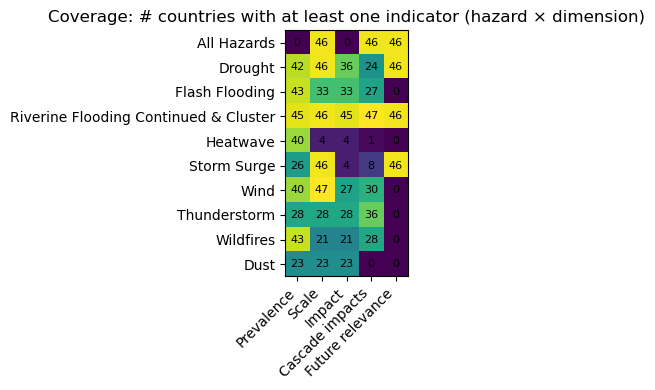

In [79]:
df_scoped = scope_filter(df_long)
plot_coverage_heatmap(df_scoped, "Coverage: # countries with at least one indicator (hazard × dimension)",
                      outpath=os.path.join(FIG_DIR, "coverage_hazard_dimension.png"))


### Indicator inventory (what exists; what is scoring vs QA-only)

In [80]:
meta = make_indicator_metadata(df_scoped)
meta["in_scoring_set"] = meta["indicator_id"].isin(SCORING_INDICATORS)
meta["qa_only_explicit"] = meta["indicator_id"].isin(QA_ONLY_INDICATORS)

display_cols = ["indicator_id","indicator_name","source","dimension","hazard","hazard_applicability","unit_raw","time_window","in_scoring_set","qa_only_explicit"]
display(meta[display_cols].sort_values(["dimension","hazard_applicability","source","indicator_id"]).reset_index(drop=True))


,indicator_id,indicator_name,source,dimension,hazard,hazard_applicability,unit_raw,time_window,in_scoring_set,qa_only_explicit
0,INFORM.DIM.LACK_COPING,INFORM dimension: Lack of Coping Capacity (pro...,INFORM Risk,Cascade impacts,All Hazards,hazard-agnostic,index_0_10,annual_snapshot,False,False
1,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Drought,hazard-specific,count_people,2000-2024,False,True
2,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Riverine Flooding Continued & Cluster,hazard-specific,count_people,2000-2024,False,True
3,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Wind,hazard-specific,count_people,2000-2024,False,True
4,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Thunderstorm,hazard-specific,count_people,2000-2024,False,True
...,...,...,...,...,...,...,...,...,...,...
245,INFORM.HAZEX.TROPICAL_CYCLONE,Hazard & exposure: Tropical Cyclone (proxy for...,INFORM Risk,Scale,Wind,hazard-specific,index_0_10,annual_snapshot,True,False
246,WRI.EI_03,Exposure to coastal flooding (EI_03) — proxy f...,WorldRiskIndex,Scale,Storm Surge,hazard-specific,index_0_100,annual_snapshot,False,False
247,WRI.EI_04,Exposure to riverine flooding (EI_04),WorldRiskIndex,Scale,Riverine Flooding Continued & Cluster,hazard-specific,index_0_100,annual_snapshot,False,False
248,WRI.EI_05,Exposure to cyclones (EI_05) — proxy for wind,WorldRiskIndex,Scale,Wind,hazard-specific,index_0_100,annual_snapshot,False,False


## 4) Run scenarios (default + sensitivity)

In [81]:
results = {}
for s in SCENARIOS.keys():
    results[s] = run_scenario(df_long, pop, s)

print("Scenarios computed:", list(results.keys()))


[QA] rows with value_raw but missing score_01: 0


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:526: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")


[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:620: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_index(name="hazard_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:653: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["is_exposure_gated"] = out["is_exposure_gated"].fillna(True)


,iso3,country,region
414,REU,Réunion (France),Southern Africa


...

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:526: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:620: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).rese

[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


,iso3,country,region
414,REU,Réunion (France),Southern Africa


Scenarios computed: ['S_main', 'S_noAgnostic', 'S_gapFillOnly', 'S_futureHazOnly', 'S_overlapArbitration']


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1095852932.py:687: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")


In [82]:
s = DEFAULT_SCENARIO

hs = results[s]["hazard_scores"]
scn = results[s]["scoring_norm"]

print("Central Africa — hazard ranking (pop-weighted):")
display(results[s]["region_scores_popw"].query("region=='Central Africa'")
        .sort_values("rank_hazards_within_region_popw"))

print("Storm Surge gating check — Central Africa:")
display(
    hs.query("region=='Central Africa' and hazard=='Storm Surge'")
      .sort_values("hazard_score_raw", ascending=False)
      [["iso3","country","hazard_score_raw","hazard_score","is_exposure_gated","n_presence_hits","presence_indicators"]]
)

print("Riverine Flood gating check — Central Africa:")
display(
    hs.query("region=='Central Africa' and hazard=='Riverine Flooding Continued & Cluster'")
      .sort_values("hazard_score_raw", ascending=False)
      [["iso3","country","hazard_score_raw","hazard_score","is_exposure_gated","n_presence_hits","presence_indicators"]]
)

print("Dust sanity check — ensure it doesn't get wiped out:")
display(
    hs.query("region=='Central Africa' and hazard=='Dust'")
      .sort_values("hazard_score_raw", ascending=False)
      [["iso3","country","hazard_score_raw","hazard_score","is_exposure_gated","n_presence_hits","presence_indicators"]]
      .head(20)
)


Central Africa — hazard ranking (pop-weighted):


,region,hazard,region_hazard_score_popw,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.767328,1.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.511566,2.0
5,Central Africa,Storm Surge,0.458913,3.0
0,Central Africa,Drought,0.451411,4.0
2,Central Africa,Flash Flooding,0.442923,5.0
3,Central Africa,Heatwave,0.331813,6.0
6,Central Africa,Thunderstorm,0.310842,7.0
1,Central Africa,Dust,0.291855,8.0
8,Central Africa,Wind,0.179225,9.0


Storm Surge gating check — Central Africa:


,iso3,country,hazard_score_raw,hazard_score,is_exposure_gated,n_presence_hits,presence_indicators
265,GAB,Gabon,0.945455,0.945455,False,2.0,"[INFORM.HAZEX.COASTAL_FLOOD, TH.CF_LEVEL]"
220,CMR,Cameroon,0.775758,0.775758,False,2.0,"[INFORM.HAZEX.COASTAL_FLOOD, TH.CF_LEVEL]"
283,STP,São Tomé and Príncipe,0.674603,0.674603,False,1.0,[INFORM.HAZEX.COASTAL_FLOOD]
247,COG,Congo (Brazzaville),0.642857,0.642857,False,1.0,[INFORM.HAZEX.COASTAL_FLOOD]
274,GNQ,Equatorial Guinea,0.605051,0.605051,False,2.0,"[INFORM.HAZEX.COASTAL_FLOOD, TH.CF_LEVEL]"
256,COD,DR Congo,0.457143,0.457143,False,1.0,[INFORM.HAZEX.COASTAL_FLOOD]
238,TCD,Chad,0.000000,0.000000,True,0.0,NaN
229,CAF,Central African Rep.,0.000000,0.000000,True,0.0,NaN


Riverine Flood gating check — Central Africa:


,iso3,country,hazard_score_raw,hazard_score,is_exposure_gated,n_presence_hits,presence_indicators
236,TCD,Chad,0.834509,0.834509,False,2.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, TH.FL_LEVEL]"
245,COG,Congo (Brazzaville),0.732172,0.732172,False,1.0,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
281,STP,São Tomé and Príncipe,0.530129,0.530129,False,1.0,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
227,CAF,Central African Rep.,0.519030,0.519030,False,2.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, TH.FL_LEVEL]"
254,COD,DR Congo,0.477662,0.477662,False,1.0,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
263,GAB,Gabon,0.419700,0.419700,False,2.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, TH.FL_LEVEL]"
218,CMR,Cameroon,0.384540,0.384540,False,2.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, TH.FL_LEVEL]"
272,GNQ,Equatorial Guinea,0.321862,0.321862,False,1.0,[TH.FL_LEVEL]


Dust sanity check — ensure it doesn't get wiped out:


,iso3,country,hazard_score_raw,hazard_score,is_exposure_gated,n_presence_hits,presence_indicators
260,COD,DR Congo,0.459407,0.459407,False,1.0,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
233,CAF,Central African Rep.,0.165289,0.165289,False,1.0,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
224,CMR,Cameroon,NaN,0.000000,True,NaN,NaN
242,TCD,Chad,NaN,0.000000,True,NaN,NaN
251,COG,Congo (Brazzaville),NaN,0.000000,True,NaN,NaN
269,GAB,Gabon,NaN,0.000000,True,NaN,NaN
278,GNQ,Equatorial Guinea,NaN,0.000000,True,NaN,NaN
287,STP,São Tomé and Príncipe,NaN,0.000000,True,NaN,NaN


### Overlap dashboard (plain-language)

**Overlap** = cases where **more than one source** provides the same *construct* (e.g., deaths rate) for the same country & hazard.

If overlap is high, scoring both sources counts the same concept twice.
We compute overlap rates and (optionally) apply **construct arbitration** for affected/deaths/events when overlap ≥ threshold.


,hazard,construct,n_cases,n_overlap,overlap_rate
0,Drought,affected_rate,36,0,0.0
3,Dust,affected_rate,23,0,0.0
5,Flash Flooding,affected_rate,33,0,0.0
8,Heatwave,affected_rate,4,0,0.0
11,Riverine Flooding Continued & Cluster,affected_rate,45,0,0.0
14,Storm Surge,affected_rate,4,0,0.0
17,Thunderstorm,affected_rate,28,0,0.0
20,Wildfires,affected_rate,21,0,0.0
23,Wind,affected_rate,26,0,0.0
1,Drought,deaths_rate,15,0,0.0


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1628248841.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


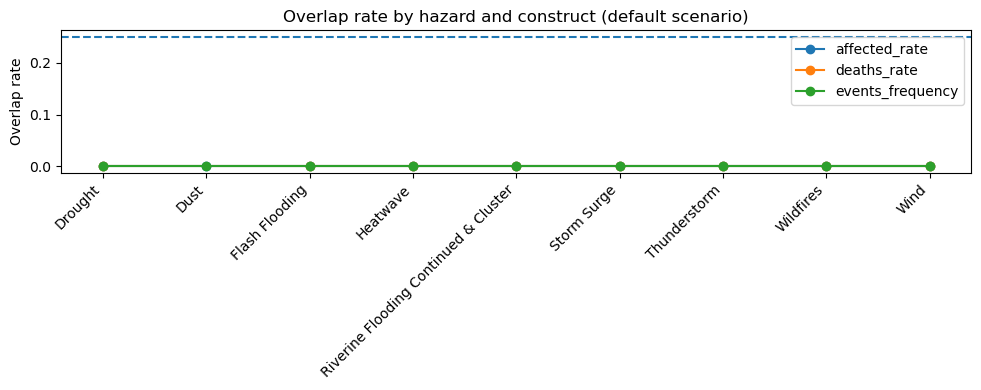

In [83]:
display(results[DEFAULT_SCENARIO]["overlap"])

# simple plot: overlap rate by construct
ov = results[DEFAULT_SCENARIO]["overlap"].copy()
if not ov.empty:
    fig, ax = plt.subplots(figsize=(10,4))
    for construct in ov["construct"].unique():
        sub = ov[ov["construct"].eq(construct)].sort_values("overlap_rate")
        ax.plot(sub["hazard"], sub["overlap_rate"], marker="o", label=construct)
    ax.axhline(OVERLAP_THRESHOLD, linestyle="--")
    ax.set_ylabel("Overlap rate")
    ax.set_title("Overlap rate by hazard and construct (default scenario)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "overlap_rates.png"), dpi=200)
    plt.show()


## 5) Scenario comparison (how rankings change)

We compare the **default scenario** against sensitivity scenarios to show how much decisions matter.


In [84]:
def get_region_ranks(scenario: str) -> pd.DataFrame:
    popw = results[scenario]["region_scores_popw"].copy()
    popw = popw[["region","hazard","region_hazard_score_popw","rank_hazards_within_region_popw"]]
    popw = popw.rename(columns={
        "region_hazard_score_popw": f"score_popw_{scenario}",
        "rank_hazards_within_region_popw": f"rank_popw_{scenario}",
    })
    return popw

base = get_region_ranks(DEFAULT_SCENARIO)
comp = base
for scenario in ["S_noAgnostic","S_gapFillOnly","S_futureHazOnly","S_overlapArbitration"]:
    comp = comp.merge(get_region_ranks(scenario), on=["region","hazard"], how="left")

display(comp.sort_values(["region","rank_popw_"+DEFAULT_SCENARIO]).reset_index(drop=True))


,region,hazard,score_popw_S_main,rank_popw_S_main,score_popw_S_noAgnostic,rank_popw_S_noAgnostic,score_popw_S_gapFillOnly,rank_popw_S_gapFillOnly,score_popw_S_futureHazOnly,rank_popw_S_futureHazOnly,score_popw_S_overlapArbitration,rank_popw_S_overlapArbitration
0,Central Africa,Wildfires,0.767328,1.0,0.767328,1.0,0.767328,1.0,0.767328,1.0,0.767328,1.0
1,Central Africa,Riverine Flooding Continued & Cluster,0.511566,2.0,0.511566,2.0,0.511566,2.0,0.511566,2.0,0.511566,2.0
2,Central Africa,Storm Surge,0.458913,3.0,0.458913,3.0,0.458913,3.0,0.458913,3.0,0.458913,3.0
3,Central Africa,Drought,0.451411,4.0,0.451411,4.0,0.451411,4.0,0.451411,4.0,0.451411,4.0
4,Central Africa,Flash Flooding,0.442923,5.0,0.442923,5.0,0.442923,5.0,0.442923,5.0,0.442923,5.0
5,Central Africa,Heatwave,0.331813,6.0,0.331813,6.0,0.331813,6.0,0.331813,6.0,0.331813,6.0
6,Central Africa,Thunderstorm,0.310842,7.0,0.310842,7.0,0.310842,7.0,0.310842,7.0,0.310842,7.0
7,Central Africa,Dust,0.291855,8.0,0.291855,8.0,0.291855,8.0,0.291855,8.0,0.291855,8.0
8,Central Africa,Wind,0.179225,9.0,0.179225,9.0,0.179225,9.0,0.179225,9.0,0.179225,9.0
9,East Africa,Heatwave,0.792399,1.0,0.792399,1.0,0.792399,1.0,0.792399,1.0,0.792399,1.0


## 6) Country outputs (default scenario)

These are the core country-level ranking outputs used for WP3.


In [85]:
results[DEFAULT_SCENARIO]["regional_contributors"]

,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share
252,Central Africa,Drought,COD,DR Congo,109276265.0,0.430556,0.595485
234,Central Africa,Drought,TCD,Chad,20299123.0,0.682407,0.175322
216,Central Africa,Drought,CMR,Cameroon,29123744.0,0.407099,0.150059
225,Central Africa,Drought,CAF,Central African Rep.,5330690.0,0.526852,0.035546
243,Central Africa,Drought,COG,Congo (Brazzaville),6332961.0,0.304762,0.024428
...,...,...,...,...,...,...,...
50,West Africa,Wind,NER,Niger,27032412.0,0.000000,NaN
59,West Africa,Wind,CIV,Côte d'Ivoire,31934230.0,0.000000,NaN
68,West Africa,Wind,BEN,Benin,14462724.0,0.000000,NaN
77,West Africa,Wind,TGO,Togo,9515236.0,0.000000,NaN


In [86]:
haz_scores = results[DEFAULT_SCENARIO]["hazard_scores"].copy()
display(haz_scores.sort_values(["hazard","rank_countries_within_hazard"]).head(30))

# Example: one country profile — which hazards rank highest?
example_iso = haz_scores["iso3"].dropna().unique()[0]
profile = haz_scores[haz_scores["iso3"].eq(example_iso)].sort_values("rank_hazards_within_country")
print("Example country:", example_iso, profile["country"].iloc[0])
display(profile[["hazard","hazard_score","rank_hazards_within_country","n_dimensions_used"]])


,iso3,hazard,country,region,hazard_score,n_dimensions_used,n_presence_hits,presence_indicators,presence_dimensions,hazard_score_raw,is_exposure_gated,is_missing_hazard_row,rank_hazards_within_country,rank_countries_within_hazard
324,NAM,Drought,Namibia,Southern Africa,0.865432,4,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.865432,False,False,2.0,1.0
171,SOM,Drought,Somalia,East Africa,0.857361,5,2.0,"[INFORM.HAZEX.DROUGHT, TH.DG_LEVEL]","[Prevalence, Scale]",0.857361,False,False,3.0,2.0
306,ZWE,Drought,Zimbabwe,Southern Africa,0.813120,5,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.813120,False,False,1.0,3.0
360,LSO,Drought,Lesotho,Southern Africa,0.754321,4,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.754321,False,False,2.0,4.0
297,ZMB,Drought,Zambia,Southern Africa,0.717671,5,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.717671,False,False,3.0,5.0
198,ERI,Drought,Eritrea,East Africa,0.705247,4,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.705247,False,False,5.0,6.0
288,ZAF,Drought,South Africa,Southern Africa,0.702778,4,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.702778,False,False,4.0,7.0
207,DJI,Drought,Djibouti,East Africa,0.688281,5,2.0,"[INFORM.HAZEX.DROUGHT, TH.DG_LEVEL]","[Prevalence, Scale]",0.688281,False,False,4.0,8.0
234,TCD,Drought,Chad,Central Africa,0.682407,4,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.682407,False,False,5.0,9.0
351,MWI,Drought,Malawi,Southern Africa,0.668654,5,3.0,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.668654,False,False,3.0,10.0


Example country: NGA Nigeria


,hazard,hazard_score,rank_hazards_within_country,n_dimensions_used
7,Wildfires,1.000000,1.0,1
4,Storm Surge,0.798291,2.0,4
2,Riverine Flooding Continued & Cluster,0.767193,3.0,5
8,Dust,0.737968,4.0,2
3,Heatwave,0.500000,5.0,3
1,Flash Flooding,0.429466,6.0,3
6,Thunderstorm,0.428219,7.0,3
0,Drought,0.309877,8.0,4
5,Wind,0.000000,9.0,3


## 7) Regional hazard prioritisation (default scenario)

We provide **two** region rankings:
- **Population‑weighted** (intended WP3 regional hazard prioritisation)
- **Unweighted** (sensitivity: each country counts equally)


,region,hazard,region_hazard_score_popw,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.767328,1.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.511566,2.0
5,Central Africa,Storm Surge,0.458913,3.0
0,Central Africa,Drought,0.451411,4.0
2,Central Africa,Flash Flooding,0.442923,5.0
3,Central Africa,Heatwave,0.331813,6.0
6,Central Africa,Thunderstorm,0.310842,7.0
1,Central Africa,Dust,0.291855,8.0
8,Central Africa,Wind,0.179225,9.0
12,East Africa,Heatwave,0.792399,1.0


,region,hazard,region_hazard_score_unweighted,rank_hazards_within_region_unweighted
7,Central Africa,Wildfires,0.588452,1.0
3,Central Africa,Heatwave,0.562500,2.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.527450,3.0
2,Central Africa,Flash Flooding,0.521049,4.0
5,Central Africa,Storm Surge,0.512608,5.0
0,Central Africa,Drought,0.380323,6.0
6,Central Africa,Thunderstorm,0.255605,7.0
1,Central Africa,Dust,0.078087,8.0
8,Central Africa,Wind,0.065328,9.0
12,East Africa,Heatwave,0.803977,1.0


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


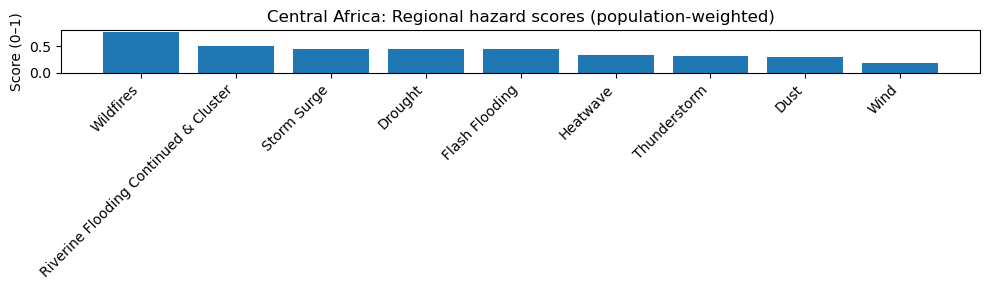

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


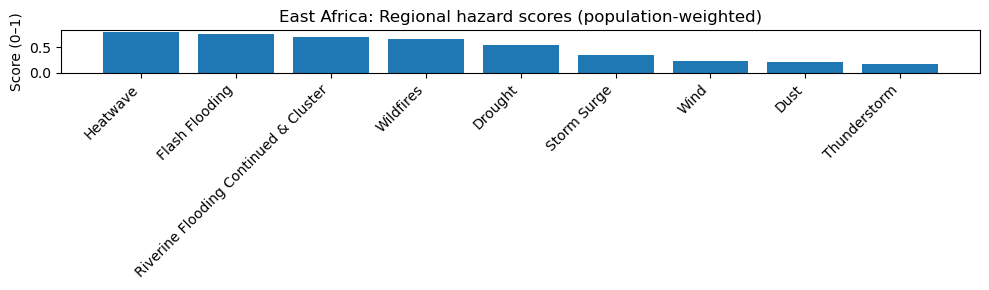

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


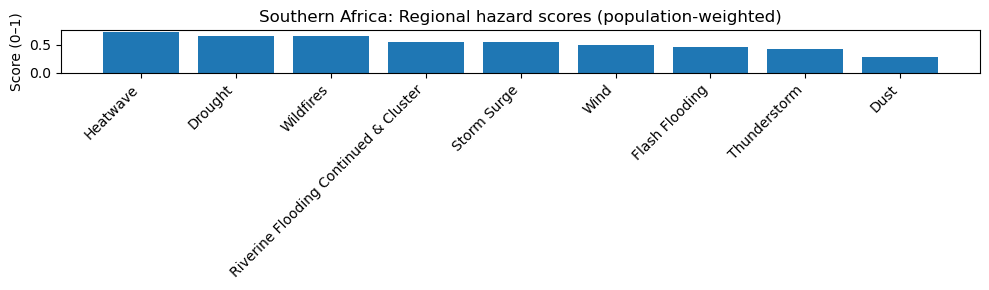

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


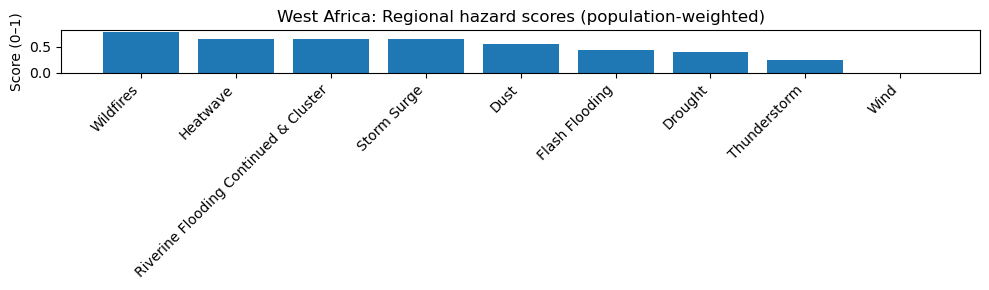

In [87]:
popw = results[DEFAULT_SCENARIO]["region_scores_popw"].copy()
unw = results[DEFAULT_SCENARIO]["region_scores_unweighted"].copy()

display(popw.sort_values(["region","rank_hazards_within_region_popw"]))
display(unw.sort_values(["region","rank_hazards_within_region_unweighted"]))

# Plot: region hazard scores (pop-weighted)
for region in popw["region"].dropna().unique():
    sub = popw[popw["region"].eq(region)].sort_values("region_hazard_score_popw", ascending=False)
    fig, ax = plt.subplots(figsize=(10,3))
    ax.bar(sub["hazard"], sub["region_hazard_score_popw"])
    ax.set_title(f"{region}: Regional hazard scores (population-weighted)")
    ax.set_ylabel("Score (0–1)")
    ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"region_popw_{re.sub('[^A-Za-z0-9]+','_',region)}.png"), dpi=200)
    plt.show()


### Which countries drive each regional hazard score? (population‑weighted)

This module shows, for each region × hazard, which countries contribute most to the **population‑weighted** regional score.


,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share
252,Central Africa,Drought,COD,DR Congo,109276265.0,0.430556,0.595485
234,Central Africa,Drought,TCD,Chad,20299123.0,0.682407,0.175322
216,Central Africa,Drought,CMR,Cameroon,29123744.0,0.407099,0.150059
225,Central Africa,Drought,CAF,Central African Rep.,5330690.0,0.526852,0.035546
243,Central Africa,Drought,COG,Congo (Brazzaville),6332961.0,0.304762,0.024428
261,Central Africa,Drought,GAB,Gabon,2538952.0,0.319192,0.010257
270,Central Africa,Drought,GNQ,Equatorial Guinea,1892516.0,0.371717,0.008904
279,Central Africa,Drought,STP,São Tomé and Príncipe,235536.0,0.000000,0.000000
260,Central Africa,Dust,COD,DR Congo,109276265.0,0.459407,0.982752
233,Central Africa,Dust,CAF,Central African Rep.,5330690.0,0.165289,0.017248


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1208632452.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["country"], rotation=45, ha="right")


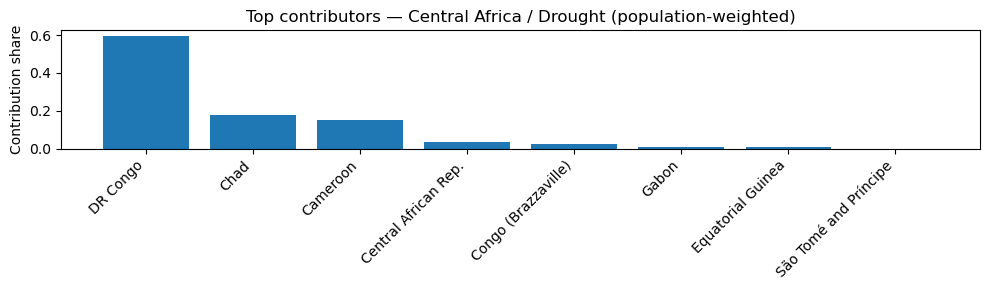

In [88]:
contrib = results[DEFAULT_SCENARIO]["regional_contributors"].copy()
display(contrib.head(50))

# Example plot for one region/hazard
example = contrib.dropna().iloc[0]
reg = example["region"]; haz = example["hazard"]
sub = contrib[(contrib["region"].eq(reg)) & (contrib["hazard"].eq(haz))].sort_values("contribution_share", ascending=False)
fig, ax = plt.subplots(figsize=(10,3))
ax.bar(sub["country"], sub["contribution_share"])
ax.set_title(f"Top contributors — {reg} / {haz} (population-weighted)")
ax.set_ylabel("Contribution share")
ax.set_xticklabels(sub["country"], rotation=45, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"contributors_{re.sub('[^A-Za-z0-9]+','_',reg)}_{re.sub('[^A-Za-z0-9]+','_',haz)}.png"), dpi=200)
plt.show()


## 8) Explainability: exactly which indicators contributed

For any country × hazard, we can show the dimension score + the indicator scores used to build it.


In [89]:
def explain_country_hazard(iso3: str, hazard: str, scenario: str = DEFAULT_SCENARIO) -> None:
    scoring_norm = results[scenario]["scoring_norm"].copy()
    dim = results[scenario]["dimension_scores"].copy()
    sel = scoring_norm[(scoring_norm["iso3"].eq(iso3)) & (scoring_norm["hazard"].eq(hazard))].copy()
    if sel.empty:
        print("No scoring indicators for", iso3, hazard, "in scenario", scenario)
        return

    print(f"Explainability — {iso3} / {hazard} / {scenario}")
    display(dim[(dim["iso3"].eq(iso3)) & (dim["hazard"].eq(hazard))].sort_values("dimension"))

    display(sel[["dimension","indicator_id","indicator_name","source","value_raw","score_01","hazard_applicability","agnostic_mode"]]
            .sort_values(["dimension","hazard_applicability","indicator_id"])
            .reset_index(drop=True))

# Demo example
iso3_demo = results[DEFAULT_SCENARIO]["hazard_scores"]["iso3"].dropna().unique()[0]
haz_demo = results[DEFAULT_SCENARIO]["hazard_scores"][results[DEFAULT_SCENARIO]["hazard_scores"]["iso3"].eq(iso3_demo)]["hazard"].iloc[0]
explain_country_hazard(iso3_demo, haz_demo)


Explainability — NGA / Drought / S_main


,iso3,country,region,hazard,dimension,dimension_score,n_indicators_used
634,NGA,Nigeria,West Africa,Drought,Future relevance,0.144444,1
635,NGA,Nigeria,West Africa,Drought,Impact,0.100000,1
636,NGA,Nigeria,West Africa,Drought,Prevalence,0.550000,2
637,NGA,Nigeria,West Africa,Drought,Scale,0.477778,2


,dimension,indicator_id,indicator_name,source,value_raw,score_01,hazard_applicability,agnostic_mode
0,Future relevance,INFORMCC.CHG_HAZEX.DROUGHT.2050.pessimistic,"Change in Hazard & Exposure: Drought (2050, pe...",INFORM Climate Change,0.900000,0.144444,hazard-specific,NaN
1,Impact,EM-DAT.AFFECTED_PER100K_2000_2024,Affected per 100k (Pop2024),EM-DAT (selected),8213.185866,0.100000,hazard-specific,NaN
2,Prevalence,EM-DAT.EVENTS_PER_YEAR_2000_2024,Events per year (total / 25y),EM-DAT (selected),0.040000,0.100000,hazard-specific,NaN
3,Prevalence,TH.DG_LEVEL,ThinkHazard hazard level: Water scarcity,ThinkHazard!,4.000000,1.000000,hazard-specific,NaN
4,Scale,INFORM.HAZEX.DROUGHT,Hazard & exposure: Drought,INFORM Risk,3.100000,0.377778,hazard-specific,NaN
5,Scale,WRI.EI_06,Exposure to droughts (EI_06),WorldRiskIndex,3.210000,0.577778,hazard-specific,NaN


## 9) Export (CSV + Excel workbook)

We export:
- A folder of CSV outputs
- One Excel workbook with multiple sheets (country scores, region scores, contributors, coverage, overlap, scenario comparison, indicator metadata)
- The figures saved under `outputs/wp3_prioritisation/figures/`


In [90]:
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.worksheet.table import Table, TableStyleInfo

def style_sheet(ws, title: str) -> None:
    ws.freeze_panes = "A2"
    ws.sheet_view.showGridLines = False
    ws["A1"].font = Font(bold=True)
    ws["A1"].alignment = Alignment(horizontal="left", vertical="center")
    ws["A1"].value = title

def write_df(ws, df: pd.DataFrame, start_row: int = 2, start_col: int = 1) -> Tuple[int,int]:
    for r_idx, row in enumerate(dataframe_to_rows(df, index=False, header=True), start=start_row):
        for c_idx, value in enumerate(row, start=start_col):
            ws.cell(row=r_idx, column=c_idx, value=value)
    nrows = len(df) + 1
    ncols = len(df.columns)
    # header style
    header_fill = PatternFill("solid", fgColor="1F4E79")  # dark blue
    header_font = Font(color="FFFFFF", bold=True)
    for c in range(start_col, start_col + ncols):
        cell = ws.cell(row=start_row, column=c)
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    # basic column widths
    for i, col in enumerate(df.columns, start=start_col):
        ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = max(12, min(40, int(len(str(col))*1.2 + 10)))
    return nrows, ncols

def add_excel_table(ws, nrows: int, ncols: int, start_row: int = 2, start_col: int = 1, name: str = "Table1"):
    end_row = start_row + nrows - 1
    end_col = start_col + ncols - 1
    ref = f"{openpyxl.utils.get_column_letter(start_col)}{start_row}:{openpyxl.utils.get_column_letter(end_col)}{end_row}"
    table = Table(displayName=name, ref=ref)
    style = TableStyleInfo(name="TableStyleMedium9", showRowStripes=True, showColumnStripes=False)
    table.tableStyleInfo = style
    ws.add_table(table)

def excel_safe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Make a DataFrame safe for openpyxl by converting list/dict/set cells to strings.
    Keeps the table readable in Excel.
    """
    out = df.copy()
    obj_cols = out.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        out[c] = out[c].map(
            lambda v: ", ".join(v) if isinstance(v, (list, tuple, set))
            else (str(v) if isinstance(v, dict) else v)
        )
    return out

def export_excel(results: dict, out_path: str) -> None:
    wb = openpyxl.Workbook()
    # remove default sheet
    wb.remove(wb.active)

    def add_sheet(name: str, title: str, df: pd.DataFrame, table_name: str):
        ws = wb.create_sheet(title=name)
        style_sheet(ws, title)
        df2 = excel_safe_df(df)   # <-- add this line
        nrows, ncols = write_df(ws, df2, start_row=2, start_col=1)
        add_excel_table(ws, nrows=nrows, ncols=ncols, start_row=2, start_col=1, name=table_name)


    # Build key tables for default scenario
    s = DEFAULT_SCENARIO
    add_sheet("Country_Hazard_Scores", "Country hazard scores & ranks (default scenario)", 
              results[s]["hazard_scores"].sort_values(["hazard","rank_countries_within_hazard"]), "CountryHazardScores")
    add_sheet("Country_Dimension_Scores", "Dimension scores (country × hazard × dimension)", 
              results[s]["dimension_scores"].sort_values(["hazard","iso3","dimension"]), "CountryDimensionScores")
    add_sheet("Region_PopWeighted", "Regional hazard prioritisation (population-weighted)", 
              results[s]["region_scores_popw"].sort_values(["region","rank_hazards_within_region_popw"]), "RegionPopW")
    add_sheet("Region_Unweighted", "Regional hazard prioritisation (unweighted)", 
              results[s]["region_scores_unweighted"].sort_values(["region","rank_hazards_within_region_unweighted"]), "RegionUnW")
    add_sheet("Regional_Contributors", "Top contributing countries to each region×hazard (pop-weighted)", 
              results[s]["regional_contributors"].sort_values(["region","hazard","contribution_share"], ascending=[True,True,False]), "RegionalContrib")
    add_sheet("Overlap_QA", "Overlap report (where multiple sources measure the same construct)", 
              results[s]["overlap"], "OverlapQA")
    add_sheet("Indicator_Metadata", "Indicator metadata & applicability (hazard-specific vs hazard-agnostic)", 
              results[s]["meta"].sort_values(["dimension","hazard_applicability","source","indicator_id"]), "IndicatorMeta")

    # Scenario comparison table (region pop-weighted ranks)
    # reuse the comp table from earlier
    comp_df = comp.copy() if "comp" in globals() else pd.DataFrame()
    if not comp_df.empty:
        add_sheet("Scenario_Comparison", "Scenario comparison (region pop-weighted)", comp_df, "ScenarioComp")

    # README tab
    ws = wb.create_sheet(title="README")
    ws.sheet_view.showGridLines = False
    ws["A1"].value = "WP3 Africa Multi-Hazard Prioritisation — Outputs"
    ws["A1"].font = Font(bold=True, size=14)
    ws["A3"].value = "Default scenario:"
    ws["B3"].value = DEFAULT_SCENARIO
    ws["A5"].value = "Notes:"
    ws["A6"].value = "- Scores are 0–1 after percentile normalisation (higher = worse)."
    ws["A7"].value = "- Region_PopWeighted uses WDI SP.POP.TOTL population weights (Pop_2024)."
    ws["A8"].value = "- Overlap_QA explains where multiple sources measured the same construct."
    ws["A10"].value = "Key sources (methods/definitions):"
    ws["A11"].value = "Population definition (WDI SP.POP.TOTL): https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SP.POP.TOTL"
    ws["A12"].value = "Composite indicators handbook (OECD/JRC): https://www.oecd.org/en/publications/handbook-on-constructing-composite-indicators_533411815016.html"
    ws["A13"].value = "ThinkHazard methods: https://gfdrr.github.io/thinkhazardmethods/"
    ws["A14"].value = "EM-DAT economic adjustment: https://doc.emdat.be/docs/protocols/economic-adjustment/"
    ws.column_dimensions["A"].width = 120

    wb.save(out_path)

# Export
excel_path = os.path.join(OUT_DIR, "WP3_Hazard_Prioritisation_Outputs_RankNorm.xlsx")
export_excel(results, excel_path)
print("Excel written:", excel_path)

# CSV exports (default scenario)
def export_csv_tables(results: dict, scenario: str):
    os.makedirs(OUT_DIR, exist_ok=True)
    tables = {
        "indicator_metadata": results[scenario]["meta"],
        "scoring_raw": results[scenario]["scoring_raw"],
        "scoring_norm": results[scenario]["scoring_norm"],
        "qa_only": results[scenario]["qa"],
        "overlap": results[scenario]["overlap"],
        "dimension_scores": results[scenario]["dimension_scores"],
        "hazard_scores": results[scenario]["hazard_scores"],
        "region_scores_popw": results[scenario]["region_scores_popw"],
        "region_scores_unweighted": results[scenario]["region_scores_unweighted"],
        "regional_contributors": results[scenario]["regional_contributors"],
    }
    for name, df in tables.items():
        df.to_csv(os.path.join(OUT_DIR, f"{name}__{scenario}.csv"), index=False)

export_csv_tables(results, DEFAULT_SCENARIO)
print("CSVs written under:", OUT_DIR)


Excel written: C:\pipelines\sewa-multihazar\data\output\wp3_prioritisation\WP3_Hazard_Prioritisation_Outputs_RankNorm.xlsx
CSVs written under: C:\pipelines\sewa-multihazar\data\output\wp3_prioritisation


In [91]:
sc = results[DEFAULT_SCENARIO]["scoring_norm"]

def show_indicator_drivers(iso3, region, hazard, dimension=None):
    q = f"iso3 == @iso3 and region == @region and hazard == @hazard"
    if dimension is not None:
        q += " and dimension == @dimension"
    cols = ["iso3","country","region","hazard","dimension","indicator_id","source",
            "value_raw","score_01","hazard_applicability","agnostic_mode"]
    out = (sc.query(q)[cols]
             .sort_values(["dimension","score_01"], ascending=[True, False]))
    return out

# Example: CAF storm surge drivers
display(show_indicator_drivers("BEN", "West Africa", "Dust"))

,iso3,country,region,hazard,dimension,indicator_id,source,value_raw,score_01,hazard_applicability,agnostic_mode
780,BEN,Benin,West Africa,Dust,Impact,EM-DAT.AFFECTED_PER100K_2000_2024,EM-DAT (selected),0.138287,0.411765,hazard-specific,NaN
781,BEN,Benin,West Africa,Dust,Prevalence,EM-DAT.EVENTS_PER_YEAR_2000_2024,EM-DAT (selected),0.040000,0.159091,hazard-specific,NaN


In [92]:
sc2 = results[DEFAULT_SCENARIO]["scoring_norm"].copy()

# count hazard-specific vs agnostic indicators per iso3×hazard
mix = (sc2.groupby(["iso3","hazard"])
          .agg(
              n_ind=("indicator_id","nunique"),
              n_hazard_specific=("hazard_applicability", lambda s: (s=="hazard-specific").sum()),
              n_hazard_agnostic=("hazard_applicability", lambda s: (s=="hazard-agnostic").sum()),
          )
          .reset_index())

mix["share_agnostic"] = mix["n_hazard_agnostic"] / mix["n_ind"].replace(0, np.nan)

# join to hazard_scores and sort suspicious cases
hs = results[DEFAULT_SCENARIO]["hazard_scores"].merge(mix, on=["iso3","hazard"], how="left")
sus = (hs.query("hazard == 'Storm Surge'")
         .sort_values(["share_agnostic","hazard_score"], ascending=[False, False]))

display(sus[["iso3","country","region","hazard_score","n_ind","share_agnostic"]].head(30))


,iso3,country,region,hazard_score,n_ind,share_agnostic
265,GAB,Gabon,Central Africa,0.945455,3.0,0.0
103,GIN,Guinea,West Africa,0.894949,3.0,0.0
85,SLE,Sierra Leone,West Africa,0.864646,3.0,0.0
211,DJI,Djibouti,East Africa,0.849495,3.0,0.0
22,SEN,Senegal,West Africa,0.840171,4.0,0.0
139,TZA,Tanzania,East Africa,0.830303,3.0,0.0
409,COM,Comoros,Southern Africa,0.829293,3.0,0.0
346,AGO,Angola,Southern Africa,0.814141,3.0,0.0
202,ERI,Eritrea,East Africa,0.808081,3.0,0.0
175,SOM,Somalia,East Africa,0.802020,3.0,0.0


In [93]:
dim = results[DEFAULT_SCENARIO]["dimension_scores"].copy()

# build full grid iso3×hazard×dimension
grid = (
    dim[["iso3","country","region","hazard"]].drop_duplicates()
    .merge(pd.DataFrame({"dimension": DIMENSIONS}), how="cross")
)

dim_full = (
    grid.merge(dim, on=["iso3","country","region","hazard","dimension"], how="left")
)

dim_full["dimension_score"] = dim_full["dimension_score"].fillna(0.0)
dim_full["dw"] = dim_full["dimension"].map(DIM_WEIGHTS).astype(float)

haz0 = (
    dim_full.groupby(["iso3","country","region","hazard"])
    .apply(lambda x: float(np.average(x["dimension_score"], weights=x["dw"])) if x["dw"].sum()>0 else np.nan)
    .reset_index(name="hazard_score_missingDimsAs0")
)

# compare ranks vs current
cur = results[DEFAULT_SCENARIO]["hazard_scores"][["iso3","hazard","hazard_score","rank_hazards_within_country"]].copy()
cmp = cur.merge(haz0, on=["iso3","hazard"], how="left")

cmp["rank_missingDimsAs0"] = cmp.groupby("iso3")["hazard_score_missingDimsAs0"].rank(ascending=False, method="min")
cmp["rank_diff"] = cmp["rank_missingDimsAs0"] - cmp["rank_hazards_within_country"]

display(cmp.sort_values(["iso3","rank_diff"], ascending=[True, False]).head(50))


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\1714560009.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: float(np.average(x["dimension_score"], weights=x["dw"])) if x["dw"].sum()>0 else np.nan)


,iso3,hazard,hazard_score,rank_hazards_within_country,country,region,hazard_score_missingDimsAs0,rank_missingDimsAs0,rank_diff
345,AGO,Heatwave,0.750000,3.0,Angola,Southern Africa,0.150000,7.0,4.0
349,AGO,Wildfires,1.000000,1.0,Angola,Southern Africa,0.200000,5.0,4.0
346,AGO,Storm Surge,0.814141,2.0,Angola,Southern Africa,0.447778,4.0,2.0
348,AGO,Thunderstorm,0.000000,7.0,Angola,Southern Africa,0.082353,8.0,1.0
347,AGO,Wind,0.000000,7.0,Angola,Southern Africa,0.177778,6.0,-1.0
343,AGO,Flash Flooding,0.642832,4.0,Angola,Southern Africa,0.578549,2.0,-2.0
344,AGO,Riverine Flooding Continued & Cluster,0.560282,6.0,Angola,Southern Africa,0.560282,3.0,-3.0
342,AGO,Drought,0.580612,5.0,Angola,Southern Africa,0.580612,1.0,-4.0
350,AGO,Dust,0.000000,7.0,NaN,NaN,NaN,NaN,NaN
165,BDI,Heatwave,0.750000,1.0,Burundi,East Africa,0.150000,8.0,7.0


# Q&A Diagnosis

In [94]:
import numpy as np
import pandas as pd

s = DEFAULT_SCENARIO
sc = results[s]["scoring_norm"].copy()
dim = results[s]["dimension_scores"].copy()
hs = results[s]["hazard_scores"].copy()

# You should already have pop loaded; sanity check:
assert "pop_2024" in pop.columns, "pop must include pop_2024 (WDI SP.POP.TOTL)"


In [95]:
# Define what counts as "Impact evidence"
IMPACT_INDICATORS = {
    "EM-DAT.DEATHS_PER100K_2000_2024",
    "DESINVENTAR.DEATHS_PER100K_2000_2024",
    "EM-DAT.AFFECTED_PER100K_2000_2024",
    "DESINVENTAR.AFFECTED_PER100K_2000_2024",
    "EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024",
    "DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024",
}

m_impact = (
    sc["indicator_id"].isin(IMPACT_INDICATORS)
    & sc["value_raw"].notna()
    & sc["hazard_applicability"].eq("hazard-specific")
)

impact_ev = (
    sc.loc[m_impact]
      .groupby(["iso3","hazard"])["indicator_id"]
      .nunique()
      .reset_index(name="n_impact_indicators")
)

# Optional: displacement evidence (kept separate)
m_disp = (
    sc["indicator_id"].eq("IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF")
    & sc["value_raw"].notna()
    & sc["hazard_applicability"].eq("hazard-specific")
)
disp_ev = (
    sc.loc[m_disp]
      .groupby(["iso3","hazard"])["indicator_id"]
      .nunique()
      .reset_index(name="n_displacement_indicators")
)

tmp = (
    hs.merge(pop[["iso3","pop_2024"]], on="iso3", how="left")
      .merge(impact_ev, on=["iso3","hazard"], how="left")
      .merge(disp_ev, on=["iso3","hazard"], how="left")
)

tmp["n_impact_indicators"] = tmp["n_impact_indicators"].fillna(0).astype(int)
tmp["n_displacement_indicators"] = tmp["n_displacement_indicators"].fillna(0).astype(int)
tmp["has_impact_evidence"] = tmp["n_impact_indicators"].gt(0)
tmp["has_displacement_evidence"] = tmp["n_displacement_indicators"].gt(0)

tmp[["iso3","country","region","hazard","hazard_score","is_exposure_gated","n_impact_indicators","n_displacement_indicators"]].head()


,iso3,country,region,hazard,hazard_score,is_exposure_gated,n_impact_indicators,n_displacement_indicators
0,NGA,Nigeria,West Africa,Drought,0.309877,False,1,0
1,NGA,Nigeria,West Africa,Flash Flooding,0.429466,False,1,0
2,NGA,Nigeria,West Africa,Riverine Flooding Continued & Cluster,0.767193,False,1,1
3,NGA,Nigeria,West Africa,Heatwave,0.500000,False,1,0
4,NGA,Nigeria,West Africa,Storm Surge,0.798291,False,0,1


In [96]:
def popw_avg(values, weights):
    m = values.notna() & weights.notna()
    if m.sum() == 0:
        return np.nan
    return float(np.average(values[m].to_numpy(), weights=weights[m].to_numpy()))

rows = []
for (region, hazard), g in tmp.groupby(["region","hazard"]):
    w = g["pop_2024"]
    rows.append({
        "region": region,
        "hazard": hazard,
        "region_hazard_score_popw": popw_avg(g["hazard_score"], w),
        "pop_share_with_impact_evidence": popw_avg(g["has_impact_evidence"].astype(float), w),
        "pop_share_with_displacement_evidence": popw_avg(g["has_displacement_evidence"].astype(float), w),
        "pop_share_gated": popw_avg(g["is_exposure_gated"].astype(float), w),
        "popw_score_if_has_impact": popw_avg(g.loc[g["has_impact_evidence"], "hazard_score"], g.loc[g["has_impact_evidence"], "pop_2024"]),
        "popw_score_if_no_impact": popw_avg(g.loc[~g["has_impact_evidence"], "hazard_score"], g.loc[~g["has_impact_evidence"], "pop_2024"]),
        "n_countries": int(g["iso3"].nunique()),
    })

evidence_region_hazard = pd.DataFrame(rows)

# Attach regional ranks from your official outputs (so we can compare)
rank_popw = results[s]["region_scores_popw"][["region","hazard","rank_hazards_within_region_popw"]].copy()

evidence_region_hazard = (
    evidence_region_hazard.merge(rank_popw, on=["region","hazard"], how="left")
      .sort_values(["region","rank_hazards_within_region_popw"])
)

display(evidence_region_hazard)


,region,hazard,region_hazard_score_popw,pop_share_with_impact_evidence,pop_share_with_displacement_evidence,pop_share_gated,popw_score_if_has_impact,popw_score_if_no_impact,n_countries,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.767328,0.665598,0.770761,0.037528,0.755724,0.790425,8,1.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.511566,1.000000,0.989187,0.000000,0.511566,NaN,8,2.0
5,Central Africa,Storm Surge,0.458913,0.000000,0.000000,0.146431,NaN,0.458913,8,3.0
0,Central Africa,Drought,0.451411,0.937154,0.000000,0.001346,0.460688,0.313086,8,4.0
2,Central Africa,Flash Flooding,0.442923,0.937154,0.806943,0.037528,0.445609,0.402862,8,5.0
3,Central Africa,Heatwave,0.331813,0.000000,0.000000,0.661857,NaN,0.331813,8,6.0
6,Central Africa,Thunderstorm,0.310842,0.796079,0.951660,0.214733,0.390466,0.000000,8,7.0
1,Central Africa,Dust,0.291855,0.654785,0.000000,0.345215,0.445727,0.000000,8,8.0
8,Central Africa,Wind,0.179225,0.649648,0.654785,0.361165,0.275881,0.000000,8,9.0
12,East Africa,Heatwave,0.792399,0.119695,0.000000,0.000000,0.343750,0.853402,11,1.0


In [97]:
contrib = results[s]["regional_contributors"].copy()
contrib = contrib.merge(tmp[["iso3","hazard","has_impact_evidence","has_displacement_evidence","is_exposure_gated"]].drop_duplicates(),
                        on=["iso3","hazard"], how="left")

# For each region×hazard, what share of the top contributors lack impact evidence?
qa_contrib = (
    contrib.groupby(["region","hazard"])
           .apply(lambda g: pd.Series({
               "top10_contrib_share_no_impact": float(g.loc[~g["has_impact_evidence"], "contribution_share"].sum()),
               "top10_contrib_share_gated": float(g.loc[g["is_exposure_gated"], "contribution_share"].sum()),
               "top10_contrib_share_no_impact_no_disp": float(g.loc[(~g["has_impact_evidence"]) & (~g["has_displacement_evidence"]), "contribution_share"].sum()),
           }))
           .reset_index()
)

qa_contrib = qa_contrib.merge(rank_popw, on=["region","hazard"], how="left").sort_values(["region","rank_hazards_within_region_popw"])
display(qa_contrib)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2471284340.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,region,hazard,top10_contrib_share_no_impact,top10_contrib_share_gated,top10_contrib_share_no_impact_no_disp,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.344468,0.0,0.235752,1.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.000000,0.0,0.000000,2.0
5,Central Africa,Storm Surge,1.000000,0.0,1.000000,3.0
0,Central Africa,Drought,0.043588,0.0,0.043588,4.0
2,Central Africa,Flash Flooding,0.057162,0.0,0.057162,5.0
3,Central Africa,Heatwave,1.000000,0.0,1.000000,6.0
6,Central Africa,Thunderstorm,0.000000,0.0,0.000000,7.0
1,Central Africa,Dust,0.000000,0.0,0.000000,8.0
8,Central Africa,Wind,0.000000,0.0,0.000000,9.0
12,East Africa,Heatwave,0.944576,0.0,0.944576,1.0


In [98]:
FLOOD_COMPLEX = ["Flash Flooding", "Riverine Flooding Continued & Cluster", "Thunderstorm"]

hs_flood = hs[hs["hazard"].isin(FLOOD_COMPLEX)].copy()

# Combine floods per iso3 (validation only):
# Option 1: max (if any flood type is high, flood complex is high)
flood_max = (hs_flood.groupby(["iso3","country","region"])
                    .agg(flood_complex_score=("hazard_score","max"))
                    .reset_index())

# Option 2: mean (more conservative)
flood_mean = (hs_flood.groupby(["iso3","country","region"])
                     .agg(flood_complex_score=("hazard_score","mean"))
                     .reset_index())

def region_popw_from_country_scores(df_country, score_col="flood_complex_score"):
    dfc = df_country.merge(pop[["iso3","pop_2024"]], on="iso3", how="left")
    out = (dfc.groupby("region")
              .apply(lambda g: popw_avg(g[score_col], g["pop_2024"]))
              .reset_index(name="region_score_popw"))
    return out

r_flood_max = region_popw_from_country_scores(flood_max, "flood_complex_score")
r_flood_mean = region_popw_from_country_scores(flood_mean, "flood_complex_score")

r_flood_max["hazard"] = "Flood complex (max of Flash/River/Thunder)"
r_flood_mean["hazard"] = "Flood complex (mean of Flash/River/Thunder)"

validation = pd.concat([r_flood_max, r_flood_mean], ignore_index=True)

# Compare against your current hazards
baseline = results[s]["region_scores_popw"][["region","hazard","region_hazard_score_popw"]].rename(
    columns={"region_hazard_score_popw":"region_score_popw"}
)

compare = pd.concat([baseline, validation], ignore_index=True)
compare = compare.sort_values(["region","region_score_popw"], ascending=[True, False])

display(compare)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2302615715.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: popw_avg(g[score_col], g["pop_2024"]))
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33696\2302615715.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: popw_avg(g[score_col], g["pop_2024"]))


,region,hazard,region_score_popw
7,Central Africa,Wildfires,0.767328
36,Central Africa,Flood complex (max of Flash/River/Thunder),0.573030
4,Central Africa,Riverine Flooding Continued & Cluster,0.511566
5,Central Africa,Storm Surge,0.458913
0,Central Africa,Drought,0.451411
2,Central Africa,Flash Flooding,0.442923
40,Central Africa,Flood complex (mean of Flash/River/Thunder),0.421777
3,Central Africa,Heatwave,0.331813
6,Central Africa,Thunderstorm,0.310842
1,Central Africa,Dust,0.291855


In [99]:
sc_nonnull = sc[sc["score_01"].notna()].copy()

cov_country_hazard = (
    sc_nonnull.groupby(["iso3","hazard"])
      .agg(
          n_rows=("indicator_id","size"),
          n_indicators=("indicator_id","nunique"),
          n_dim=("dimension","nunique"),
          share_agnostic=("hazard_applicability", lambda s: float((s=="hazard-agnostic").mean()) if len(s) else np.nan),
          share_TH=("indicator_id", lambda s: float(pd.Series(s).astype(str).str.startswith("TH.").mean()) if len(s) else np.nan),
          has_impact=("dimension", lambda s: bool((pd.Series(s)=="Impact").any())),
          has_prevalence=("dimension", lambda s: bool((pd.Series(s)=="Prevalence").any())),
          has_scale=("dimension", lambda s: bool((pd.Series(s)=="Scale").any())),
      )
      .reset_index()
)

cov_country_hazard = cov_country_hazard.merge(hs[["iso3","hazard","hazard_score"]], on=["iso3","hazard"], how="left")
cov_country_hazard = cov_country_hazard.merge(pop[["iso3","pop_2024"]], on="iso3", how="left")
cov_country_hazard = cov_country_hazard.merge(hs[["iso3","hazard","region"]].drop_duplicates(), on=["iso3","hazard"], how="left")

def popw_share_bool(g, col):
    return popw_avg(g[col].astype(float), g["pop_2024"])

def popw_mean(g, col):
    return popw_avg(g[col], g["pop_2024"])

rows=[]
for (region, hazard), g in cov_country_hazard.groupby(["region","hazard"]):
    rows.append({
        "region": region,
        "hazard": hazard,
        "popw_n_indicators": popw_mean(g, "n_indicators"),
        "popw_share_agnostic": popw_mean(g, "share_agnostic"),
        "popw_share_TH": popw_mean(g, "share_TH"),
        "pop_share_has_impact": popw_share_bool(g, "has_impact"),
        "pop_share_has_prev": popw_share_bool(g, "has_prevalence"),
        "pop_share_has_scale": popw_share_bool(g, "has_scale"),
        "region_hazard_score_popw_recomputed": popw_mean(g, "hazard_score"),
    })

cov_region_hazard = pd.DataFrame(rows).merge(rank_popw, on=["region","hazard"], how="left")
cov_region_hazard = cov_region_hazard.sort_values(["region","rank_hazards_within_region_popw"])

display(cov_region_hazard)


,region,hazard,popw_n_indicators,popw_share_agnostic,popw_share_TH,pop_share_has_impact,pop_share_has_prev,pop_share_has_scale,region_hazard_score_popw_recomputed,rank_hazards_within_region_popw
7,Central Africa,Wildfires,2.535241,0.0,0.259857,0.691550,1.000000,0.000000,0.797247,1.0
4,Central Africa,Riverine Flooding Continued & Cluster,5.300666,0.0,0.057742,1.000000,1.000000,0.973336,0.511566,2.0
5,Central Africa,Storm Surge,2.191711,0.0,0.063904,0.000000,0.191711,1.000000,0.458913,3.0
0,Central Africa,Drought,5.212450,0.0,0.058467,0.937154,0.962472,1.000000,0.451411,4.0
2,Central Africa,Flash Flooding,3.336707,0.0,0.096332,0.938417,0.963769,0.313246,0.443519,5.0
3,Central Africa,Heatwave,1.000000,0.0,1.000000,0.000000,1.000000,0.000000,0.981281,6.0
6,Central Africa,Thunderstorm,2.643004,0.0,0.000000,0.827119,0.815885,0.000000,0.322962,7.0
1,Central Africa,Dust,2.000000,0.0,0.000000,1.000000,1.000000,0.000000,0.445727,8.0
8,Central Africa,Wind,3.145793,0.0,0.089526,0.649648,0.816041,1.000000,0.179225,9.0
12,East Africa,Heatwave,1.359086,0.0,0.910229,0.119695,1.000000,0.119695,0.792399,1.0


In [100]:
def show_region_hazard_diagnosis(region, hazard, top_n=12):
    c = results[s]["regional_contributors"].copy()
    c = c[(c["region"]==region) & (c["hazard"]==hazard)].copy()
    c = c.merge(cov_country_hazard[["iso3","hazard","n_indicators","share_TH","share_agnostic","has_impact","has_prevalence","has_scale"]],
                on=["iso3","hazard"], how="left")
    return c.sort_values("contribution_share", ascending=False).head(top_n)

display(show_region_hazard_diagnosis("Central Africa", "Wildfires", top_n=15))
display(show_region_hazard_diagnosis("West Africa", "Wildfires", top_n=15))


,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share,n_indicators,share_TH,share_agnostic,has_impact,has_prevalence,has_scale
0,Central Africa,Wildfires,COD,DR Congo,109276265.0,0.754049,0.613525,3.0,0.000000,0.0,True,True,False
1,Central Africa,Wildfires,CMR,Cameroon,29123744.0,1.000000,0.216847,1.0,1.000000,0.0,False,True,False
2,Central Africa,Wildfires,TCD,Chad,20299123.0,0.719298,0.108716,2.0,0.500000,0.0,False,True,False
3,Central Africa,Wildfires,CAF,Central African Rep.,5330690.0,0.961538,0.038164,4.0,0.250000,0.0,True,True,False
4,Central Africa,Wildfires,GAB,Gabon,2538952.0,1.000000,0.018904,1.0,1.000000,0.0,False,True,False
5,Central Africa,Wildfires,GNQ,Equatorial Guinea,1892516.0,0.272727,0.003843,3.0,0.333333,0.0,True,True,False
6,Central Africa,Wildfires,COG,Congo (Brazzaville),6332961.0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
7,Central Africa,Wildfires,STP,São Tomé and Príncipe,235536.0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share,n_indicators,share_TH,share_agnostic,has_impact,has_prevalence,has_scale
0,West Africa,Wildfires,NGA,Nigeria,232679478.0,1.000000,0.663634,1,1.000000,0.0,False,True,False
1,West Africa,Wildfires,BFA,Burkina Faso,23548781.0,1.000000,0.067164,1,1.000000,0.0,False,True,False
2,West Africa,Wildfires,GHA,Ghana,34427414.0,0.681818,0.066949,3,0.333333,0.0,True,True,False
3,West Africa,Wildfires,NER,Niger,27032412.0,0.761364,0.058701,3,0.333333,0.0,True,True,False
4,West Africa,Wildfires,TGO,Togo,9515236.0,1.000000,0.027139,1,1.000000,0.0,False,True,False
5,West Africa,Wildfires,BEN,Benin,14462724.0,0.616903,0.025447,4,0.250000,0.0,True,True,False
6,West Africa,Wildfires,MLI,Mali,24478595.0,0.363636,0.025388,3,0.333333,0.0,True,True,False
7,West Africa,Wildfires,SEN,Senegal,18501984.0,0.363636,0.019189,3,0.333333,0.0,True,True,False
8,West Africa,Wildfires,SLE,Sierra Leone,8642022.0,0.676113,0.016665,4,0.250000,0.0,True,True,False
9,West Africa,Wildfires,LBR,Liberia,5612817.0,1.000000,0.016009,1,1.000000,0.0,False,True,False


In [101]:
x = norm_indicator[
    (norm_indicator["iso3"]=="KEN") &
    (norm_indicator["indicator_id"]=="IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF")
][["hazard","value_raw","score_01"]].sort_values("hazard")
display(x)


NameError: name 'norm_indicator' is not defined

# Min-Max Normalization Test

In [ ]:
# --- Sensitivity: Min-Max normalisation (continent-wide) ---
# Uses the SAME scoring set as your default scenario, only swaps the normalisation.

base = results[DEFAULT_SCENARIO]
scoring_raw = base["scoring_raw"].copy()   # pre-normalisation table used by default pipeline

def apply_normalisation_minmax(df: pd.DataFrame) -> pd.DataFrame:
    """
    Min-max normalisation to [0,1] per indicator_id over UNIQUE iso3 values (robust to replication).
    For structural-zero indicators: 0 -> 0.0, min-max computed on strictly positive values only.
    ThinkHazard categorical indicators keep TH_MAP mapping.
    """
    df = df.copy()
    df["value_raw"] = pd.to_numeric(df["value_raw"], errors="coerce")
    df["score_01"] = np.nan

    # 1) Categorical (ThinkHazard)
    is_cat = df.get("is_categorical", pd.Series(False, index=df.index)).fillna(False) | \
             df["indicator_id"].astype(str).str.startswith("TH.")
    if is_cat.any():
        vals = df.loc[is_cat, "value_raw"].round().astype("Int64")
        df.loc[is_cat, "score_01"] = vals.map(TH_MAP).astype(float)

    # 2) Continuous indicators
    def norm_indicator(g: pd.DataFrame) -> pd.DataFrame:
        ind = str(g["indicator_id"].iloc[0])

        # representative iso3 value (robust to duplicates from replication/joins)
        iso_vals = (
            g[["iso3", "value_raw"]]
            .sort_values(["iso3"])
            .groupby("iso3", as_index=False)["value_raw"]
            .first()
        )
        v = iso_vals["value_raw"]
        score = pd.Series(np.nan, index=iso_vals.index, dtype=float)

        if ZERO_IS_ZERO_PATTERN.search(ind):
            # structural zeros -> 0.0
            z = v.notna() & (v == 0)
            score.loc[z] = 0.0

            # min-max among positives only
            p = v.notna() & (v > 0)
            npos = int(p.sum())
            if npos == 1:
                score.loc[p] = 1.0
            elif npos > 1:
                vpos = v.loc[p]
                mn, mx = float(vpos.min()), float(vpos.max())
                if mx == mn:
                    score.loc[p] = 1.0
                else:
                    score.loc[p] = (vpos - mn) / (mx - mn)

        else:
            m = v.notna()
            n = int(m.sum())
            if n == 1:
                score.loc[m] = 0.5
            elif n > 1:
                vv = v.loc[m]
                mn, mx = float(vv.min()), float(vv.max())
                if mx == mn:
                    score.loc[m] = 0.5
                else:
                    score.loc[m] = (vv - mn) / (mx - mn)

        iso_vals["score_01_iso"] = score

        g = g.merge(iso_vals[["iso3", "score_01_iso"]], on="iso3", how="left")
        g["score_01"] = g["score_01_iso"].astype(float)
        return g.drop(columns=["score_01_iso"])

    cont = ~is_cat
    if cont.any():
        df = df.groupby("indicator_id", group_keys=False).apply(norm_indicator)

    # 3) Direction handling
    if "direction" in df.columns:
        m = df["direction"].eq("higher_is_better") & df["score_01"].notna()
        df.loc[m, "score_01"] = 1.0 - df.loc[m, "score_01"]

    return df

# Recompute pipeline from scoring_raw with min-max
scoring_norm_mm = apply_normalisation_minmax(scoring_raw)
dim_scores_mm = compute_dimension_scores(scoring_norm_mm)
haz_scores_mm = compute_hazard_scores(dim_scores_mm)

# Same exposure evidence + gating logic as baseline
evidence_mm = compute_hazard_evidence(scoring_norm_mm)
haz_scores_mm = apply_exposure_gating(haz_scores_mm, evidence_mm)

# Region aggregation + ranks
popw_mm, _ = aggregate_regions(haz_scores_mm, pop, year=2024)
popw_mm = rank_within_group(popw_mm, ["region"], "region_hazard_score_popw", "rank_hazards_within_region_popw")

# Compare against baseline (percentile-based)
popw_base = base["region_scores_popw"].copy()

cmp_mm = (
    popw_base.merge(popw_mm, on=["region","hazard"], suffixes=("_pct", "_minmax"))
            .assign(rank_change=lambda d: d["rank_hazards_within_region_popw_minmax"] - d["rank_hazards_within_region_popw_pct"])
            .sort_values(["region","rank_hazards_within_region_popw_pct"])
)

display(cmp_mm[[
    "region","hazard",
    "region_hazard_score_popw_pct","rank_hazards_within_region_popw_pct",
    "region_hazard_score_popw_minmax","rank_hazards_within_region_popw_minmax",
    "rank_change"
]])

# Biggest movers (rank shift >=2)
movers = cmp_mm.loc[cmp_mm["rank_change"].abs() >= 2].copy()
if len(movers):
    display(movers.sort_values(["region","rank_change"], ascending=[True, False]))

# Rank similarity per region (Spearman on ranks)
rank_corr = (
    cmp_mm.groupby("region")
          .apply(lambda d: d["rank_hazards_within_region_popw_pct"].corr(d["rank_hazards_within_region_popw_minmax"], method="spearman"))
          .reset_index(name="spearman_rank_corr")
)
display(rank_corr)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33372\923385263.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("indicator_id", group_keys=False).apply(norm_indicator)


[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33372\2675140637.py:517: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33372\2675140637.py:611: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).rese

,iso3,country,region
244,REU,Réunion (France),Southern Africa


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33372\2675140637.py:678: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")


,region,hazard,region_hazard_score_popw_pct,rank_hazards_within_region_popw_pct,region_hazard_score_popw_minmax,rank_hazards_within_region_popw_minmax,rank_change
7,Central Africa,Wildfires,0.666926,1.0,0.282939,2.0,1.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.545968,2.0,0.159625,4.0,2.0
2,Central Africa,Flash Flooding,0.467141,3.0,0.113578,6.0,3.0
1,Central Africa,Dust,0.425495,4.0,0.029430,8.0,4.0
6,Central Africa,Thunderstorm,0.378062,5.0,0.040417,7.0,2.0
0,Central Africa,Drought,0.335257,6.0,0.249654,3.0,-3.0
3,Central Africa,Heatwave,0.331813,7.0,0.962563,1.0,-6.0
5,Central Africa,Storm Surge,0.270782,8.0,0.157712,5.0,-3.0
8,Central Africa,Wind,0.157259,9.0,0.021987,9.0,0.0
12,East Africa,Heatwave,0.814426,1.0,0.660977,1.0,0.0


,region,hazard,region_hazard_score_popw_pct,rank_hazards_within_region_popw_pct,region_hazard_score_popw_minmax,rank_hazards_within_region_popw_minmax,rank_change
1,Central Africa,Dust,0.425495,4.0,0.029430,8.0,4.0
2,Central Africa,Flash Flooding,0.467141,3.0,0.113578,6.0,3.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.545968,2.0,0.159625,4.0,2.0
6,Central Africa,Thunderstorm,0.378062,5.0,0.040417,7.0,2.0
0,Central Africa,Drought,0.335257,6.0,0.249654,3.0,-3.0
5,Central Africa,Storm Surge,0.270782,8.0,0.157712,5.0,-3.0
3,Central Africa,Heatwave,0.331813,7.0,0.962563,1.0,-6.0
11,East Africa,Flash Flooding,0.659224,2.0,0.233473,6.0,4.0
15,East Africa,Thunderstorm,0.415214,6.0,0.145950,8.0,2.0
10,East Africa,Dust,0.242874,9.0,0.204773,7.0,-2.0


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_33372\923385263.py:123: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d["rank_hazards_within_region_popw_pct"].corr(d["rank_hazards_within_region_popw_minmax"], method="spearman"))


,region,spearman_rank_corr
0,Central Africa,0.266667
1,East Africa,0.650000
2,Southern Africa,0.833333
3,West Africa,0.666667


## Done ✅

You now have:
- A transparent, scenario-driven prioritisation workflow
- Country + regional hazard prioritisation (pop-weighted and unweighted)
- Overlap diagnostics + optional arbitration
- Per-hazard hazard-agnostic switches
- Full explainability (which indicators contributed)

Next steps:
- Review the indicator lock list (`SCORING_INDICATORS`) and hazard-agnostic matrix (`AGNOSTIC_PER_HAZARD`)
- Adjust weights if needed
- Re-run scenarios and re-export the Excel deliverable
